# Does selection at IGHV sites depend on the CDR-H3?

Entrenchment at sites 33, 35, 50 and 52 is interpreted structurally: these sites sit where
the CDR-H3, the light chain and the antigen converge. Of those three partners only the
CDR-H3 is inside DASM's input -- the light chain and the antigen are absent from what the
model sees, while the CDR-H3 sits in the heavy chain and varies freely across families
sharing a V gene. So it is the one partner whose contribution can be tested directly: if
the constraint at these sites really is CDR-H3-driven, the selection factor should shift
with CDR-H3 identity.

We take clonal families sharing a germline residue at a site, stratify them by CDR-H3
length, net charge or hydrophobicity, and ask whether the median log selection factor
moves. 2,475,110 rows over 100 V-region sites and 5,069 families give 1,530 substitutions
that clear 60 contributing families.

## Conclusions

**1. It moves, and the response is concentrated at CDR-H3-contacting sites.** Families are
split at the median of each CDR-H3 property within their (site, germline residue) pool, and
we ask how far the floor-corrected median log selection factor moves (Section 2a). At the
site level, clustering substitutions within sites and treating IGHV1 and IGHV3 as
independent replicates, contacting sites move 2.3-2.6x as far as the rest for CDR-H3
length, in both V families separately (IGHV1 2.64x p=0.031, IGHV3 2.32x p=0.0004; pooled
2.28x p=0.0002).

**2. Length is the descriptor that holds up; hydrophobicity only on direction.** Longer
CDR-H3 means stronger selection against leaving the germline residue at contacted sites:
27/29 entrenched substitutions down (93%, p=1.6e-06), 76% of contacting substitutions
against 36% of non-contacting ones, and the magnitude contrast replicates in both V
families. Hydrophobicity is directional too, consistently so (79% of entrenched
substitutions down; 78.6% in IGHV1 and 77.8% in IGHV3), but its magnitude contrast does not
replicate -- 7.7x in IGHV1 against 1.3x in IGHV3, the former resting on a non-contacting
median of 0.006 that a ratio cannot be built on. Charge is flat on the signed test (14/29,
48%) and null on the magnitude test in both families. So only length is quoted as a
magnitude; the other two are reported for what they are.

**3. Independently of DASM, longer CDR-H3s really do bury these sites more** -- burial rises
with the structure's own CDR-H3 length across 1,778 SAbDab structures (rho 0.21-0.46 at the
entrenched sites; median rho +0.371 there against +0.045 elsewhere, p=0.0004). No model is
involved, so none of the caveats below apply to it.

**4. But the effect is site-level, not residue-specific.** ~83% of the shift is uniform
movement of every target at a site; after removing the per-site mean, contacting and
non-contacting sites are indistinguishable. This supports *"the CDR-H3 modulates overall
constraint at the sites it contacts"* and not *"CDR-H3 identity determines which residue is
entrenched"*, which is what entrenchment would require.

**5. Contact is the organising variable, not entrenchment and not germline diversity.** With
contact frequency and substitution count in the model the entrenched-site indicator falls to
beta=-1.3, p=0.62, while contact frequency holds at beta=-13.2, p=1.8e-06. Germline
diversity is the other candidate, since contacted sites are also the diverse ones, but it is
unrelated to the size of the shift and the contact contrast holds within every level of it.

**6. The shift is redistribution, not a global offset.** A trivial alternative is that
longer CDR-H3s simply lower DASM's output everywhere. They do not: CDR-H3 length barely
moves the V-region mean (rho=+0.078, long minus short = +0.019) while the class shifts are
an order of magnitude larger and opposite in sign (contacting -0.217, non-contacting
+0.156). The claim is therefore relative, not absolute. The near-cancellation of the total
is not itself a finding -- it does not hold within V family (IGHV1 -0.054, IGHV3 +0.036).

## Design notes

**One substitution per unit** (site, germline residue, target), since entrenchment is defined
per amino-acid pair. **Median split within the (site, germline residue) pool** is primary --
it makes no monotonicity assumption.
**The clonal family is the unit of observation**; deduplication across pairs in a family is
exact. **IGHV1 and IGHV3 pooled**, with a per-family breakdown in Section 3a.

**Magnitudes are read against their own noise floor.** `delta` is a difference of two sample
medians, so an uninformative split gives a small accidental difference, and a larger one
where families are few and their selection factors widely spread. Contacting sites are both:
median IQR 0.82 against 0.57, and 392 contributing families against 1517, because they are
the polymorphic sites and their families split across several germline residues. Section 2a
measures that floor by pushing random family-level covariates through the same split and
subtracts it. Corrected, length gives 2.15x (95% CI 1.61-2.74), hydrophobicity 1.68x
(1.24-3.01) and charge 1.11x (0.56-1.79, not significant). The answer does not depend on how
the floor is removed: subtracting in the squared domain, or simply comparing substitutions
matched on family count and IQR with no correction at all, both give 2.18x for length.

**The signed tests need no such correction.** Sampling noise is symmetric, so its null is 50%
down whatever the family count -- which is why direction, not magnitude, carries Conclusion 2.

**Clustering matters for the magnitude test.** Three sites supply over half the contacting
substitutions, so per-substitution p-values (1e-13 to 1e-26) are not defensible. Section 8
reports the site-level test with IGHV1 and IGHV3 as independent replicates instead.

**Site-clustered direction is underpowered, not negative.** With 5 entrenched sites the
smallest attainable two-sided p is 0.0625, and all 5 are down.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, kruskal, mannwhitneyu, spearmanr
from statsmodels.regression.linear_model import OLS

import cdr3_stratification_util as cu
from utils import (ENTRENCHED_SITE_COLORS, add_cdr_shading, load_and_process_dasm_data,
                   load_entrenched_sites, sort_antibody_sites)

MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
V_FAMILIES = ["IGHV1", "IGHV3"]
MIN_FAMILIES = 60
POOL = ["site", "parent_aa"]
UNIT = ["site", "parent_aa", "selection_factor_target_aa"]
SASA_PATH = "_output/sasa_human_chothia_anarci.csv"
BURIAL_YLIM = (-0.03, 0.65)          # matches the paper's Figure 3D

OUTPUT_DIR = f"_output/cdr3_dependence_of_selection/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9e9d99"
GREY_DOT = "#575653"          # darker grey for scatter points

## 1. Load and prepare

Filters follow `v_families_entrenchment_dasm.ipynb`: `depth == 2`, parent codon equal to the
germline codon, target amino acid one nucleotide away, sites <= 94.

`is_germline_codon` is a **per-site** condition on the parent sequence, so the contributing
set of families differs from site to site. Section 7 checks that this does not drive the

**What this checks.** Assembles the analysis set and reports its composition.
**Conclusion.** ~2.48M (family, site, substitution) rows over 100 V-region sites from 5,069
families; IGHV3 supplies ~70%. Sites 35 and 53 are entrenched only in IGHV3.
result.

In [2]:
_, pcp_df, aa_df = load_and_process_dasm_data(
    model_name=MODEL_NAME, dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING, figures_dir="figures",
)
aa_v = cu.v_region_only(aa_df[(aa_df.depth == 2) & aa_df.v_family.isin(V_FAMILIES)])

pcp_df = cu.add_cdr3_descriptors(pcp_df)
pcp_df["pcp_index"] = pcp_df.index
pcp_df["family_key"] = pcp_df.sample_id.astype(str) + "|" + pcp_df.family.astype(str)
invalid = pcp_df[pcp_df.cdr3_aa.isna()]
print(f"{len(invalid)} of {len(pcp_df)} pairs have an invalid CDR-H3 span, "
      f"from {invalid.groupby(['sample_id', 'family']).ngroups} clonal families")

dasm_df = aa_v[aa_v.one_mutation_away & (aa_v.is_germline_codon == True)].dropna(
    subset=["log_selection_factor"])
dasm_df = dasm_df.merge(
    pcp_df[["pcp_index", "family_key"] + cu.CDR3_DESCRIPTORS], on="pcp_index")
sub_df = cu.substitution_level_selection(dasm_df)
print(f"{len(sub_df):,} (family, site, V gene, substitution) rows over "
      f"{sub_df.site.nunique()} V-region sites, {sub_df.family_key.nunique():,} families")
print(sub_df.groupby("v_family").agg(rows=("log_selection_factor", "size"),
                                     families=("family_key", "nunique"),
                                     v_genes=("v_gene", "nunique")).to_string())

Adding one_mutation_away column (vectorized)...


4 of 21752 pairs have an invalid CDR-H3 span, from 1 clonal families


2,475,110 (family, site, V gene, substitution) rows over 100 V-region sites, 5,069 families


             rows  families  v_genes
v_family                            
IGHV1      751267      1582       25
IGHV3     1723843      3487       52


In [3]:
classified = cu.classify_sites(cu.cdr3_burial_by_site(v_families=tuple(V_FAMILIES)),
                               NUMBERING)
_, _, _, _, within, between = load_entrenched_sites(NUMBERING)
# Entrenchment is called per V family. Two things matter here: calls from families we do
# not analyse (IGHV4) must not label IGHV1/IGHV3 substitutions, and a pair called only in
# IGHV3 is not entrenched in IGHV1. So keep the V family in the key.
n_all = len(within)
within = within[within.v_family.isin(V_FAMILIES)]
print(f"dropped {n_all - len(within)} entrenched-pair rows from V families not analysed "
      f"({sorted(set(load_entrenched_sites(NUMBERING)[4].v_family) - set(V_FAMILIES))})")
WITHIN_PAIRS_BY_FAMILY = {
    vf: {(str(r.site), r.amino_acid, r.target_amino_acid)
         for r in g.itertuples(index=False)}
    for vf, g in within.groupby("v_family")}
# pooled label: called in at least one of the analysed families
WITHIN_PAIRS = set().union(*WITHIN_PAIRS_BY_FAMILY.values())
ENT_SITES = sorted({s for s, _, _ in WITHIN_PAIRS}, key=cu.site_number)
for vf, ps in WITHIN_PAIRS_BY_FAMILY.items():
    print(f"  {vf}: {len(ps)} pairs at sites "
          f"{sorted({x for x, _, _ in ps}, key=cu.site_number)}")
print(f"pooled (union): {len(WITHIN_PAIRS)} pairs at sites {ENT_SITES}")
print("\nentrenched pair calls by V family (note 35 and 53 are IGHV3-only):")
print(within.groupby("v_family").agg(
    n_pairs=("site", "size"),
    sites=("site", lambda x: ",".join(sorted(set(x.astype(str)), key=cu.site_number)))
).to_string())
classified.loc[ENT_SITES, ["cdr3_burial", "cdr3_contact_freq", "antigen_burial",
                           "light_burial"]].round(3)

dropped 4 entrenched-pair rows from V families not analysed (['IGHV4'])
  IGHV1: 16 pairs at sites ['33', '50', '52']
  IGHV3: 22 pairs at sites ['33', '35', '50', '52', '53']
pooled (union): 32 pairs at sites ['33', '35', '50', '52', '53']

entrenched pair calls by V family (note 35 and 53 are IGHV3-only):
          n_pairs           sites
v_family                         
IGHV1          16        33,50,52
IGHV3          22  33,35,50,52,53


,cdr3_burial,cdr3_contact_freq,antigen_burial,light_burial
site,,,,
33,0.202,0.984,0.077,0.007
35,0.169,0.989,0.005,0.029
50,0.038,0.682,0.032,0.045
52,0.004,0.506,0.088,0.012
53,-0.000,0.250,0.155,0.001


## 2. Median split: how far does the median move?

Families are split at the median of the CDR-H3 property **within their (site, germline
residue) pool**, and `delta = median(high) - median(low)` of the log selection factor. A
binary split makes no assumption that the response is monotone in the property, which
matters for charge and hydrophobicity where it need not be.

**What this checks.** Whether the median log selection factor moves between families with a
high and a low value of each CDR-H3 property.
**Conclusion.** It moves. For length, 28 of 30 entrenched substitutions shift toward stronger
selection against leaving the germline residue.

In [4]:
N_NULL_DRAWS = 10


def null_abs_delta(df, n_draws=N_NULL_DRAWS, pool=POOL, unit=UNIT, seed=0):
    '''E|delta| at each substitution under a split that carries no information.

    A random family-level covariate has no relationship to selection, so the |delta| it
    produces is purely the difference two sample medians happen to show at that
    substitution -- its noise floor, set by how many families contribute and how spread
    their selection factors are. Averaging a few draws stabilises the per-substitution
    estimate. This is the same null a within-pool label permutation gives, in n_draws
    passes rather than a hundred, and it makes no distributional assumption.
    '''
    rng = np.random.default_rng(seed)
    fams = df.family_key.drop_duplicates()
    draws = []
    for _ in range(n_draws):
        d = df.dropna(subset=["log_selection_factor"]).merge(
            pd.DataFrame({"family_key": fams, "_r": rng.random(len(fams))}),
            on="family_key")
        fam = d[pool + ["family_key", "_r"]].drop_duplicates()
        fam["hi"] = (fam._r > fam.groupby(pool, observed=True)._r.transform("median")
                     ).astype(int)
        d = d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")
        m = d.groupby(unit + ["hi"], observed=True).log_selection_factor.median().unstack()
        draws.append((m[1] - m[0]).abs())
    return pd.concat(draws, axis=1).mean(axis=1).rename("null_abs")


def assign_hi_lo(df, descriptor, pool=POOL):
    '''Label each family high or low on the descriptor, within its pool.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"] = (fam[descriptor]
                 > fam.groupby(pool, observed=True)[descriptor].transform("median")
                 ).astype(int)
    return d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")


def binary_deltas(df, descriptor, min_families=MIN_FAMILIES, pool=POOL, unit=UNIT,
                  pairs=None, null=None):
    '''Per substitution: median(high) - median(low) on a within-pool median split.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"] = (fam[descriptor]
                 > fam.groupby(pool, observed=True)[descriptor].transform("median")
                 ).astype(int)
    d = d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")
    m = d.groupby(unit + ["hi"], observed=True).log_selection_factor.median().unstack()
    q = d.groupby(unit, observed=True).log_selection_factor.quantile([0.25, 0.75]).unstack()
    out = pd.DataFrame({
        "delta": m[1] - m[0],
        "iqr": q[0.75] - q[0.25],
        "n_families": d.groupby(unit, observed=True).family_key.nunique(),
        "n_rows": d.groupby(unit, observed=True).size(),
    })
    out = out[(out.n_families >= min_families) & out.delta.notna()].reset_index()
    out["descriptor"] = descriptor
    out["abs_delta"] = out.delta.abs()
    # |delta| is inflated by sampling noise: delta is a difference of two sample medians,
    # so even an uninformative split gives |delta| > 0, by more where families are few and
    # spread is wide. `null` supplies E|delta| under such a split for this same unit, and
    # subtracting it leaves what exceeds the accident. The signed delta needs no
    # correction (it is already unbiased), so the sign is carried through unchanged.
    if null is None:
        raise ValueError("binary_deltas needs `null` (from null_abs_delta) to report the "
                         "floor-corrected magnitude; every downstream summary uses it")
    out = out.join(null, on=unit)
    if out.null_abs.isna().any():
        raise ValueError("null is missing units present in the observed deltas")
    out["abs_delta_corrected"] = (out.abs_delta - out.null_abs).clip(lower=0)
    out["delta_corrected"] = np.sign(out.delta) * out.abs_delta_corrected
    pr = WITHIN_PAIRS if pairs is None else pairs
    out["entrenched"] = [(s, a, t) in pr for s, a, t in
                         zip(out.site, out.parent_aa, out.selection_factor_target_aa)]
    out = out.join(classified[["cdr3_contact_freq", "cdr3_burial"]], on="site")
    out["contact"] = out.cdr3_contact_freq.fillna(0)
    out["contact_class"] = np.where(out.contact > 0.5, "contacting",
                             np.where(out.contact > 0, "occasional", "non-contacting"))
    return out


NULL_POOLED = null_abs_delta(sub_df)
split = pd.concat([binary_deltas(sub_df, d, null=NULL_POOLED)
                   for d in cu.CDR3_DESCRIPTORS], ignore_index=True)
split.to_csv(f"{OUTPUT_DIR}/binary_split_by_substitution.csv", index=False)
LEN = split[split.descriptor == "cdr3_length"]
print(f"{len(LEN):,} substitutions per descriptor, {LEN.site.nunique()} sites")
print(LEN[LEN.entrenched][["site", "parent_aa", "selection_factor_target_aa", "n_families",
                           "delta", "iqr"]].round(3).to_string(index=False))

1,530 substitutions per descriptor, 100 sites
site parent_aa selection_factor_target_aa  n_families  delta   iqr
  33         A                          D        1222 -0.181 1.187
  33         D                          A          90 -0.104 0.486
  33         D                          G          90 -0.218 0.692
  33         D                          Y          90 -0.115 1.019
  33         G                          D         511 -0.216 1.234
  33         Y                          D         679 -0.417 1.063
  33         Y                          S         679 -0.180 0.880
  35         D                          H          65 -0.121 0.687
  35         D                          N          65 -0.136 0.629
  35         H                          D        1665 -0.222 1.073
  35         N                          D         399 -0.236 0.920
  50         G                          R         443  0.486 2.639
  50         G                          W         263 -0.234 1.624
  50         N  

### 2a. Correcting `delta` for its own noise floor

`delta` is a difference of two sample medians, so an uninformative split does not give
zero -- it gives a small accidental difference, larger where families are few and their
selection factors widely spread. Both vary across the V region: contacting sites carry a
median IQR of 0.82 against 0.57 elsewhere and a median 392 contributing families against
1517, because they are the polymorphic sites and their families split across several
germline residues. So `|delta|` is inflated more at contacting sites, and a raw magnitude
contrast between the classes could in principle be reporting that rather than the CDR-H3.

`null_abs_delta` measures that floor directly, in four steps:

1. **One random number per clonal family.** A family-level property exactly like CDR-H3
   length, but with no relationship to anything.
2. **Split it the same way the real descriptor is split.** Within each `(site, germline
   residue)` pool, a family is `hi` if its random number exceeds that pool's median. Same
   pool, same median split, same balanced halves.
3. **Compute `delta` per substitution and take `|delta|`.** Because the label carries no
   information, this magnitude is purely the accidental difference between two sample
   medians at that substitution -- set by how many families contribute and how spread
   their selection factors are.
4. **Repeat `N_NULL_DRAWS` times and average**, since one draw is a noisy estimate of the
   floor.

`binary_deltas` then subtracts it: `abs_delta_corrected = clip(|delta| - null_abs, 0)`.
The signed `delta` needs no correction -- symmetric noise has no preferred direction, so
its null is 50% down regardless of sample size -- which is why only the magnitude is
touched.

A within-pool permutation of the real high/low labels targets the same null and agrees
with this (per-substitution Spearman rho 0.97 against 100 replicates), but needs ten times
the passes and is harder to state. Two properties of the estimate are worth keeping in
mind: the floor is measured on the same data it is subtracted from, so any spread the
CDR-H3 itself creates is subtracted along with the accident and the corrected ratios are
lower bounds; and the correction is right on average rather than per substitution, so a
point sitting at zero is not distinguishable from its floor rather than shown to be null.

**What this checks.** Whether the magnitude contrast survives removing the floor,
descriptor by descriptor.
**Conclusion.** For length it does, essentially unchanged (2.17 -> 2.19). The answer is
insensitive to how the floor is removed: subtracting in the squared domain gives 2.18, and
comparing only substitutions matched on family count and IQR -- no correction at all --
also gives 2.18. Hydrophobicity and charge fall to ~1.5 and ~1.1 with intervals spanning
1, so neither supports a magnitude claim; only length should be quoted.


In [5]:
def corrected_magnitude_test(s, n_boot=2000, seed=0):
    '''Contacting vs non-contacting |delta|, before and after the variance correction.

    The bootstrap resamples substitutions within each class; it is the honest summary
    here because the Mann-Whitney is computed over units that share sites and germline
    residues and is therefore pseudo-replicated.
    '''
    c = s[s.contact_class == "contacting"]
    n = s[s.contact_class == "non-contacting"]
    # A class whose median corrects to zero makes the ratio undefined; that happens when
    # over half its substitutions fail to clear their own floor, which is a result worth
    # seeing rather than a number worth patching over.
    if n.abs_delta_corrected.median() == 0 or c.abs_delta_corrected.median() == 0:
        raise ValueError(
            "a class median corrects to zero, so the ratio is undefined: "
            f"contacting {(c.abs_delta_corrected == 0).mean():.0%} and non-contacting "
            f"{(n.abs_delta_corrected == 0).mean():.0%} of substitutions are at the floor")
    rng = np.random.default_rng(seed)
    boot = np.array([c.abs_delta_corrected.iloc[rng.integers(0, len(c), len(c))].median()
                     / n.abs_delta_corrected.iloc[rng.integers(0, len(n), len(n))].median()
                     for _ in range(n_boot)])
    if not np.isfinite(boot).all():
        raise ValueError(f"{(~np.isfinite(boot)).sum()} of {n_boot} bootstrap resamples "
                         "had a zero denominator; the corrected medians are too close "
                         "to the floor for a ratio to be meaningful")
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {
        "n_contacting": len(c), "n_non_contacting": len(n),
        "raw_ratio": c.abs_delta.median() / n.abs_delta.median(),
        "corrected_ratio": (c.abs_delta_corrected.median()
                            / n.abs_delta_corrected.median()),
        "ci_lo": lo, "ci_hi": hi,
        "mw_p": mannwhitneyu(c.abs_delta_corrected, n.abs_delta_corrected,
                             alternative="greater").pvalue,
        "obs_over_floor_c": c.abs_delta.median() / c.null_abs.median(),
        "obs_over_floor_nc": n.abs_delta.median() / n.null_abs.median(),
        # a class-dependent zero-collapse rate would bias the corrected ratio; for
        # length the two are close (19% vs 22%), for the weak descriptors they are not
        "zero_contacting": (c.abs_delta_corrected == 0).mean(),
        "zero_non_contacting": (n.abs_delta_corrected == 0).mean()}


mag = pd.DataFrame([dict(descriptor=d,
                         **corrected_magnitude_test(split[split.descriptor == d]))
                    for d in cu.CDR3_DESCRIPTORS])
mag.to_csv(f"{OUTPUT_DIR}/corrected_magnitude_test.csv", index=False)
for r in mag.itertuples(index=False):
    print(f"{r.descriptor:22s} raw {r.raw_ratio:.2f}x -> corrected "
          f"{r.corrected_ratio:.2f}x  [95% CI {r.ci_lo:.2f}, {r.ci_hi:.2f}]  "
          f"MW p={r.mw_p:.2g}")
    print(f"{'':22s} observed/floor {r.obs_over_floor_c:.2f} / "
          f"{r.obs_over_floor_nc:.2f}   "
          f"corrected to zero: {100*r.zero_contacting:.0f}% / "
          f"{100*r.zero_non_contacting:.0f}%")


cdr3_length            raw 2.17x -> corrected 2.15x  [95% CI 1.61, 2.74]  MW p=2.5e-11
                       observed/floor 3.42 / 4.58   corrected to zero: 15% / 18%
cdr3_charge            raw 1.97x -> corrected 1.11x  [95% CI 0.56, 1.79]  MW p=0.26
                       observed/floor 1.60 / 2.36   corrected to zero: 35% / 26%
cdr3_hydrophobicity    raw 2.23x -> corrected 1.68x  [95% CI 1.24, 3.01]  MW p=0.0028
                       observed/floor 1.56 / 2.04   corrected to zero: 35% / 30%


In [6]:
def sign_summary(d, label):
    '''Descriptive only. The single inferential test is in the final section.'''
    return {"group": label, "n": len(d), "pct_down": 100 * (d.delta < 0).mean(),
            "median_delta": d.delta.median(), "median_abs": d.abs_delta_corrected.median()}


rows = []
for desc in cu.CDR3_DESCRIPTORS:
    s = split[split.descriptor == desc]
    o = s[~s.entrenched]
    for label, d in [("entrenched", s[s.entrenched]),
                     ("all others", o),
                     ("others, contacting", o[o.contact_class == "contacting"]),
                     ("others, occasional", o[o.contact_class == "occasional"]),
                     ("others, non-contacting", o[o.contact_class == "non-contacting"])]:
        rows.append({"descriptor": desc, **sign_summary(d, label)})
sign_table = pd.DataFrame(rows)
sign_table.to_csv(f"{OUTPUT_DIR}/sign_test_by_group.csv", index=False)

# substitutions within a site are not independent, so also test at the site level
ent_len = LEN[LEN.entrenched]
n_sub_down = int((ent_len.delta < 0).sum())
ps = ent_len.groupby("site").delta.median()
N_DOWN, N_SITES = int((ps < 0).sum()), len(ps)
P_SITE = binomtest(N_DOWN, N_SITES, 0.5).pvalue
print(f"CDR-H3 length, entrenched: {n_sub_down}/{len(ent_len)} substitutions down "
      f"(p={binomtest(n_sub_down, len(ent_len), 0.5).pvalue:.2e} treating them as independent)")
print(f"CLUSTERED BY SITE: {N_DOWN}/{N_SITES} sites down, p={P_SITE:.4f} (two-sided).")
print("With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the")
print("site-clustered test is underpowered rather than negative.")
print(ent_len.groupby("site").agg(n_subs=("delta", "size"),
                                  n_down=("delta", lambda x: (x < 0).sum()),
                                  median_delta=("delta", "median")).round(3).to_string())
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(sign_table[sign_table.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))

CDR-H3 length, entrenched: 27/29 substitutions down (p=1.62e-06 treating them as independent)
CLUSTERED BY SITE: 5/5 sites down, p=0.0625 (two-sided).
With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the
site-clustered test is underpowered rather than negative.
      n_subs  n_down  median_delta
site                              
33         7       7        -0.181
35         4       4        -0.179
50        10       9        -0.371
52         6       5        -0.223
53         2       2        -0.269

=== cdr3_length ===
                 group    n  pct_down  median_delta  median_abs
            entrenched   29   93.1034       -0.2215      0.1558
            all others 1501   52.8981       -0.0080      0.0670
    others, contacting  273   76.1905       -0.1673      0.1336
    others, occasional  633   58.6098       -0.0222      0.0535
others, non-contacting  595   36.1345        0.0394      0.0629

=== cdr3_charge ===
                 group    n  pct_down  med

### Figure 1 --- what the median split actually compares

The primary analysis in one picture. For each entrenched substitution, families are split at
the median CDR-H3 length of their pool, and the two boxes are the log selection factors of
the LOW and HIGH halves. The orange arrow is `delta`, the movement in the median. The boxes
are wide -- CDR-H3 explains a few percent of the variance in any one substitution -- and the
result is the consistency of the arrow across substitutions, not its size relative to the
spread.

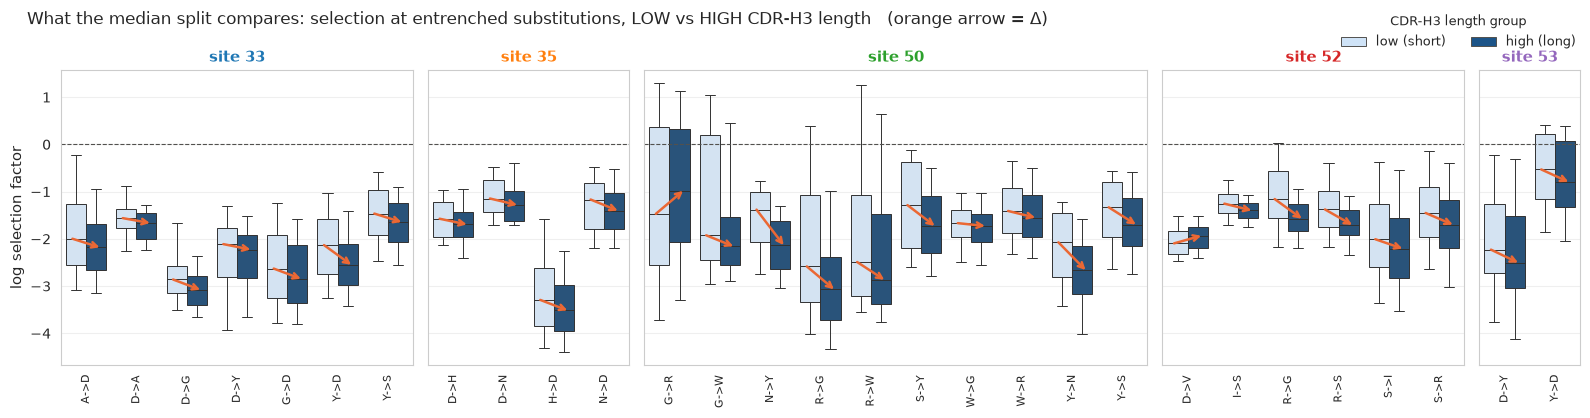

In [7]:
def entrenched_example(bins, colors, labels, fname, title, ylab_note=""):
    '''Raw log selection factors at the entrenched substitutions, split into `bins` groups.'''
    fam = sub_df[POOL + ["family_key", "cdr3_length"]].drop_duplicates()
    if bins == 2:
        fam["grp"] = (fam.cdr3_length
                      > fam.groupby(POOL, observed=True).cdr3_length.transform("median")
                      ).astype(int)
    else:
        fam["grp"] = fam.groupby(POOL, observed=True).cdr3_length.transform(
            lambda x: pd.qcut(x, bins, labels=False, duplicates="drop"))
    b = sub_df.merge(fam[POOL + ["family_key", "grp"]], on=POOL + ["family_key"],
                     how="left").dropna(subset=["grp"])
    b["substitution"] = b.parent_aa + "->" + b.selection_factor_target_aa
    # restrict to the same units the statistics use: entrenched AND passing min_families
    keep = set(zip(LEN.site, LEN.parent_aa, LEN.selection_factor_target_aa))
    ent = b[[(s, a, t) in WITHIN_PAIRS and (s, a, t) in keep for s, a, t in
             zip(b.site, b.parent_aa, b.selection_factor_target_aa)]]
    subs_by_site = {s: sorted(g.substitution.unique())
                    for s, g in ent.groupby("site", observed=True)}
    sites = [s for s in ENT_SITES if s in subs_by_site]
    fig, axes = plt.subplots(1, len(sites), figsize=(16, 4.2), sharey=True,
                             gridspec_kw={"width_ratios": [len(subs_by_site[s])
                                                           for s in sites]})
    for ax, site in zip(np.atleast_1d(axes), sites):
        subs = subs_by_site[site]
        d = ent[ent.site == site]
        sns.boxplot(data=d, x="substitution", y="log_selection_factor", hue="grp",
                    order=subs, palette=colors, showfliers=False, whis=[5, 95],
                    linewidth=0.7, ax=ax, legend=False)
        med = d.groupby(["substitution", "grp"], observed=True).log_selection_factor.median()
        for i, sub in enumerate(subs):
            lo, hi = med.get((sub, 0)), med.get((sub, bins - 1))
            if lo is not None and hi is not None:
                ax.annotate("", xy=(i + 0.27, hi), xytext=(i - 0.27, lo),
                            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.8,
                                            shrinkA=0, shrinkB=0), zorder=6)
        ax.axhline(0, color="#52514e", lw=0.8, ls="--")
        ax.set_title(f"site {site}", fontsize=11, fontweight="bold",
                     color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel("log selection factor", fontsize=10.5)
    handles = [plt.matplotlib.patches.Patch(facecolor=c, edgecolor="#52514e", lw=0.7)
               for c in colors]
    fig.legend(handles, labels, title=f"CDR-H3 length{ylab_note}", ncol=len(labels),
               fontsize=9, title_fontsize=9, loc="upper right",
               bbox_to_anchor=(0.995, 1.0), frameon=False)
    fig.suptitle(title, fontsize=12, x=0.02, ha="left")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()


entrenched_example(2, ["#cfe3f7", "#1c5488"], ["low (short)", "high (long)"],
                   "fig1_binary_split_example.pdf",
                   "What the median split compares: selection at entrenched substitutions, "
                   "LOW vs HIGH CDR-H3 length   (orange arrow = $\\Delta$)",
                   ylab_note=" group")

## 3. Along the V region

Every substitution as a point, against site, with structural burial by the CDR-H3 below in
the paper's Figure 3D convention (`burial = -rsa_vdj_junction_effect`, whiskers 5--95%). Two
renderings of the same data: points, then boxplots per site.

**What this checks.** Where along the V region the response sits, against structural burial
by the CDR-H3 on the same site axis.
**Conclusion.** Negative shifts concentrate at sites the CDR-H3 reaches (31-35, 50-52,
93-94), matching the burial track below. Sites 2-4 are an exception: frequently contacted but
shifting upward.

In [8]:
sa = pd.read_csv(SASA_PATH, dtype={"site": str},
                 usecols=["pdb_id", "v_gene_heavy", "site", "chain_id", "heavy_chain_id",
                          "rsa_heavy_only", "rsa_vdj_junction_effect",
                          "rsa_antigen_effect", "rsa_light_effect"])
sa = sa[(sa.chain_id == sa.heavy_chain_id)
        & sa.v_gene_heavy.str.extract(r"(IGHV\d+)")[0].isin(V_FAMILIES)]
# keep the unfiltered frame: Section 7 needs the 95-102 window to measure CDR-H3 length,
# which v_region_only (sites <= 94) would remove
sa_all = sa.copy()
sa = cu.v_region_only(sa)
sa_b = sa.dropna(subset=["rsa_vdj_junction_effect"]).copy()
sa_b["burial_by_vdj_junction"] = -sa_b.rsa_vdj_junction_effect

SITES = sort_antibody_sites(sorted(set(split.site) & set(sa_b.site), key=cu.site_number))


def ent_sites_for(v_family=None):
    '''Sites with an entrenched pair in this V family (union of both if None).'''
    pairs = WITHIN_PAIRS if v_family is None else WITHIN_PAIRS_BY_FAMILY[v_family]
    return sorted({x for x, _, _ in pairs}, key=cu.site_number)


def pal_for(v_family=None):
    '''Box colours: only sites entrenched IN THIS V FAMILY are coloured.'''
    es = set(ent_sites_for(v_family))
    return [ENTRENCHED_SITE_COLORS.get(s, "#e0e0e0") if s in es else "#e0e0e0"
            for s in SITES]


VALUE_LAB = {"delta": "signed", "abs_delta": "|$\\Delta$|",
             "delta_corrected": "signed, corrected",
             "abs_delta_corrected": "|$\\Delta$| corrected"}
LAB = {"cdr3_length": "CDR-H3 length", "cdr3_charge": "CDR-H3 net charge",
       "cdr3_hydrophobicity": "CDR-H3 hydrophobicity"}


def burial_panel(ax, v_family=None):
    '''Structural burial track. v_family restricts to that family's structures.'''
    b = sa_b[sa_b.site.isin(SITES)]
    if v_family is not None:
        b = b[b.v_gene_heavy.str.extract(r"(IGHV\d+)")[0] == v_family]
    ax.set_axisbelow(True)
    sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,
                palette=pal_for(v_family), whis=[5, 95], showfliers=False, width=0.7,
                ax=ax)
    add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
    ax.set_ylim(*BURIAL_YLIM)
    ax.set_ylabel("$\\Delta$ RSA CDR3\n(burial by CDR-H3)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(len(SITES)))
    ax.set_xticklabels(SITES, rotation=90, fontsize=7)
    for lbl in ax.get_xticklabels():
        if lbl.get_text() in ent_sites_for(v_family):
            lbl.set_color(ENTRENCHED_SITE_COLORS.get(lbl.get_text(), BLUE))
            lbl.set_fontweight("bold")
    tag = f"{v_family} structures only" if v_family else "IGHV1 + IGHV3 pooled"
    ax.set_xlabel(f"site (Chothia)   —   {tag} "
                  f"(n={b.pdb_id.nunique():,})", fontsize=11)


def along_v_region(kind, fname, title, data=None, value="delta", ylab=None,
                   v_family=None):
    '''One row of panels per CDR-H3 descriptor, plus the structural burial track.

    kind   "points" (one dot per substitution) or "box" (boxplot over substitutions)
    value  "delta" (signed) or "abs_delta" (magnitude)
    data   defaults to the pooled `split`; pass a subset for a per-V-family version
    '''
    src = split if data is None else data
    fig, axes = plt.subplots(4, 1, figsize=(17, 13.6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 3, 3, 2], "hspace": 0.20})
    rng = np.random.default_rng(1)
    for ax, desc in zip(axes[:3], cu.CDR3_DESCRIPTORS):
        s = src[(src.descriptor == desc) & src.site.isin(SITES)].copy()
        s["site"] = pd.Categorical(s.site, categories=SITES, ordered=True)
        add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
        ax.axhline(0, color="#3d3c3a", lw=1.0, zorder=3)
        if kind == "points":
            idx = {v: i for i, v in enumerate(SITES)}
            x = s.site.map(idx).to_numpy() + (rng.random(len(s)) - 0.5) * 0.55
            ax.scatter(x[~s.entrenched], s[value][~s.entrenched], s=16, c=GREY_DOT,
                       alpha=0.6, lw=0, zorder=4)
            for site in sorted({x for x, _, _ in (WITHIN_PAIRS if v_family is None
                                             else WITHIN_PAIRS_BY_FAMILY[v_family])},
                           key=cu.site_number):
                m = (s.entrenched & (s.site.astype(str) == site)).to_numpy()
                ax.scatter(x[m], s[value][m], s=52,
                           color=ENTRENCHED_SITE_COLORS.get(site, BLUE),
                           edgecolor="white", lw=0.7, zorder=6)
            med = s.groupby("site", observed=True)[value].median().reindex(SITES)
            for i, mm in enumerate(med):
                if np.isfinite(mm):
                    ax.plot([i - 0.36, i + 0.36], [mm, mm], color="#1a1a1a", lw=1.6,
                            zorder=7, alpha=0.8)
        else:
            # 5-95% whiskers, matching sasa_plotting.py and the paper's Figure 3D.
            # Full-range whiskers were tried and rejected: their reach grows with the
            # number of substitutions at a site, and entrenched sites are the busiest
            # (27-63 vs a median of 12), so they would stretch exactly the sites the
            # argument rests on. Fig 2 plots every substitution, so nothing is hidden.
            sns.boxplot(data=s, x="site", y=value, order=SITES,
                        palette=pal_for(v_family), whis=[5, 95], showfliers=False,
                        width=0.7, linewidth=0.7, ax=ax, zorder=4)
            e = s[s.entrenched]      # already labelled with this family's pairs
            if len(e):
                sns.stripplot(data=e, x="site", y=value, order=SITES, hue="site",
                              palette={x: ENTRENCHED_SITE_COLORS.get(x, BLUE) for x in SITES},
                              size=5.5, jitter=0.18, edgecolor="white", linewidth=0.6,
                              legend=False, ax=ax, zorder=7)
        pre = ylab if ylab else "$\\Delta$ log selection factor"
        ax.set_ylabel(f"{pre}\nhigh $-$ low {LAB[desc]}", fontsize=10)
        ax.set_xlabel(""); ax.grid(True, axis="y", alpha=0.3)
        # full data range with a small pad: nothing is clipped
        lo, hi = float(s[value].min()), float(s[value].max())
        pad = 0.04 * (hi - lo) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)
        # title reports the column actually plotted, so the raw and variance-corrected
        # versions of this figure cannot be confused for one another
        m = s.groupby("contact_class", observed=True)[value].median()
        cc, nn = m.get("contacting", np.nan), m.get("non-contacting", np.nan)
        ratio = (f"   |   ratio {cc / nn:.2f}x"
                 if value.startswith("abs_") and np.isfinite(nn) and nn != 0 else "")
        ax.set_title(f"{LAB[desc]}   {VALUE_LAB[value]} median: contacting {cc:+.3f}, "
                     f"non-contacting {nn:+.3f}{ratio}",
                     loc="left", fontsize=9.5, pad=5)
    burial_panel(axes[3], v_family=v_family)
    fig.suptitle(title, fontsize=13, x=0.02, ha="left")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

### 3a. Per-family numbers

IGHV3 supplies ~70% of the data, 30% of pooled units draw on both families, and sites 35 and
53 are entrenched only in IGHV3. So it matters whether the pooled result is carried by IGHV3
alone.

**What this checks.** Whether the pooled result replicates in each V family separately.
**Conclusion.** For length it does: IGHV1 gives 13/14 entrenched substitutions down and
IGHV3 18/18, with floor-corrected magnitude ratios of 2.18x and 2.05x -- the two families
agree closely, so neither carries the result alone. The other two descriptors do not
replicate: hydrophobicity gives 7.69x in IGHV1 against 1.30x in IGHV3, and charge 1.76x
against 0.62x, i.e. reversed. Ratios built on a near-zero denominator (IGHV1
non-contacting medians of 0.006 for hydrophobicity) are unstable by construction, which is
why the per-family columns matter more than the pooled row.

In [9]:
fam_rows = []
split_by_family = {}
for vf in V_FAMILIES + ["pooled"]:
    d_vf = sub_df if vf == "pooled" else sub_df[sub_df.v_family == vf]
    # the null depends on the families and their spread, not on the descriptor, so it is
    # computed once per subset and shared across the three CDR-H3 properties
    null_vf = NULL_POOLED if vf == "pooled" else null_abs_delta(d_vf)
    per_desc = []
    pairs_vf = WITHIN_PAIRS if vf == "pooled" else WITHIN_PAIRS_BY_FAMILY[vf]
    for desc in cu.CDR3_DESCRIPTORS:
        s = binary_deltas(d_vf, desc, pairs=pairs_vf, null=null_vf)
        per_desc.append(s)
        e = s[s.entrenched]; c = s[(~s.entrenched) & (s.contact_class == "contacting")]
        n = s[(~s.entrenched) & (s.contact_class == "non-contacting")]
        fam_rows.append({
            "v_family": vf, "descriptor": desc, "n_units": len(s), "n_ent": len(e),
            "ent_pct_down": 100 * (e.delta < 0).mean() if len(e) else np.nan,
            "ent_median": e.delta.median() if len(e) else np.nan,
            "contacting_median": c.delta.median(), "noncontact_median": n.delta.median(),
            "abs_contacting": c.abs_delta_corrected.median(),
            "abs_noncontact": n.abs_delta_corrected.median(),
            "abs_ratio": c.abs_delta_corrected.median() / n.abs_delta_corrected.median(),
            "rho_abs_contact": spearmanr(s.contact, s.abs_delta_corrected)[0],
            "p_abs_contact": spearmanr(s.contact, s.abs_delta_corrected)[1]})
    split_by_family[vf] = pd.concat(per_desc, ignore_index=True)
by_family = pd.DataFrame(fam_rows)
by_family.to_csv(f"{OUTPUT_DIR}/by_v_family.csv", index=False)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(by_family[by_family.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))


=== cdr3_length ===
v_family  n_units  n_ent  ent_pct_down  ent_median  contacting_median  noncontact_median  abs_contacting  abs_noncontact  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1      912     14       92.8571     -0.1429            -0.0900            -0.0088          0.0830          0.0380     2.1813           0.0385         0.2458
   IGHV3     1093     18      100.0000     -0.3460            -0.1964             0.0865          0.1601          0.0781     2.0487           0.1870         0.0000
  pooled     1530     29       93.1034     -0.2215            -0.1673             0.0394          0.1336          0.0629     2.1244           0.1163         0.0000

=== cdr3_charge ===
v_family  n_units  n_ent  ent_pct_down  ent_median  contacting_median  noncontact_median  abs_contacting  abs_noncontact  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1      912     14       42.8571      0.0037            -0.0400             0.0177          0.0247          0.0140     1.7623       

### 3b. Along the V region, separately for IGHV1 and IGHV3

Visual check that the pooled picture is not carried by IGHV3 alone. Three panels per V
family: the raw signed change, the same change after subtracting each substitution's own
noise floor, and the magnitude of the corrected change.

The corrected panels are the honest magnitude view. Each point is reduced by the accident
its own family count and spread produce, so a substitution that does not clear its own
floor lands exactly on zero and sites whose apparent spread was imprecision rather than
signal collapse to the axis. Individual corrected points remain noisy estimates -- a point
at zero is not distinguishable from its floor, not proven null -- so the claims rest on
medians over many substitutions, not on single points.


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


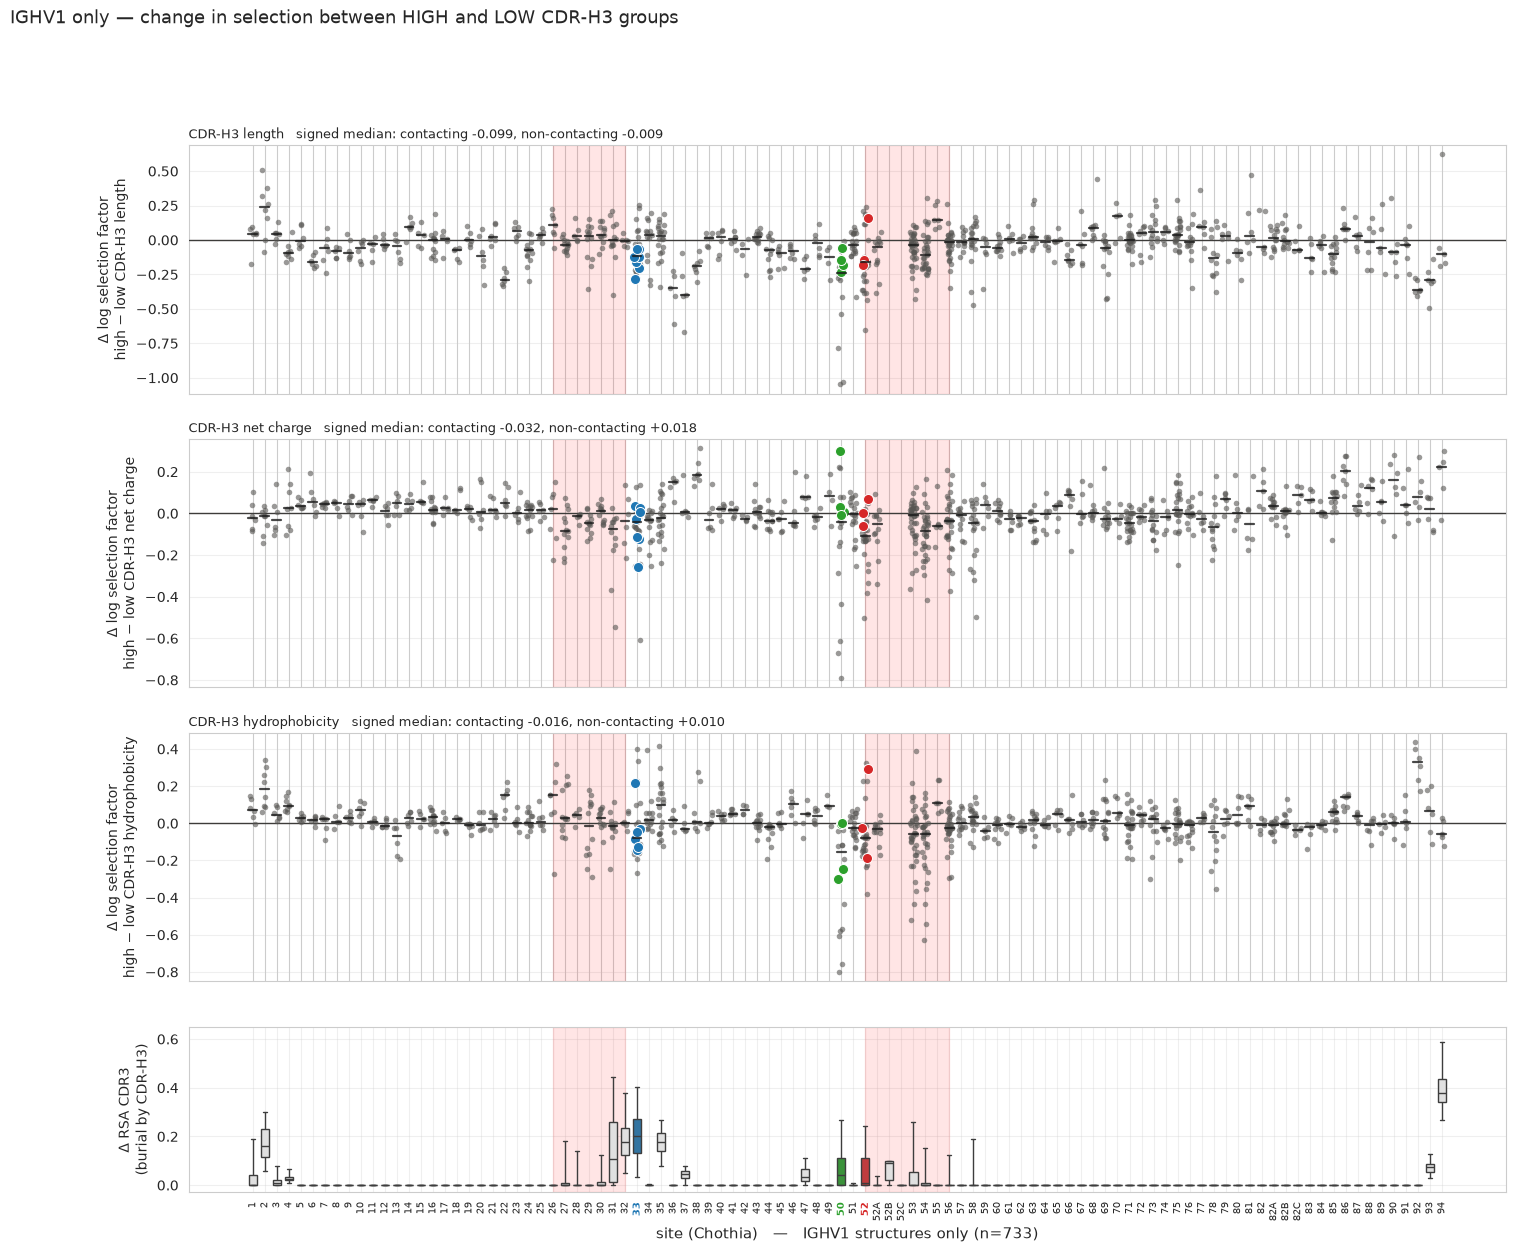

/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


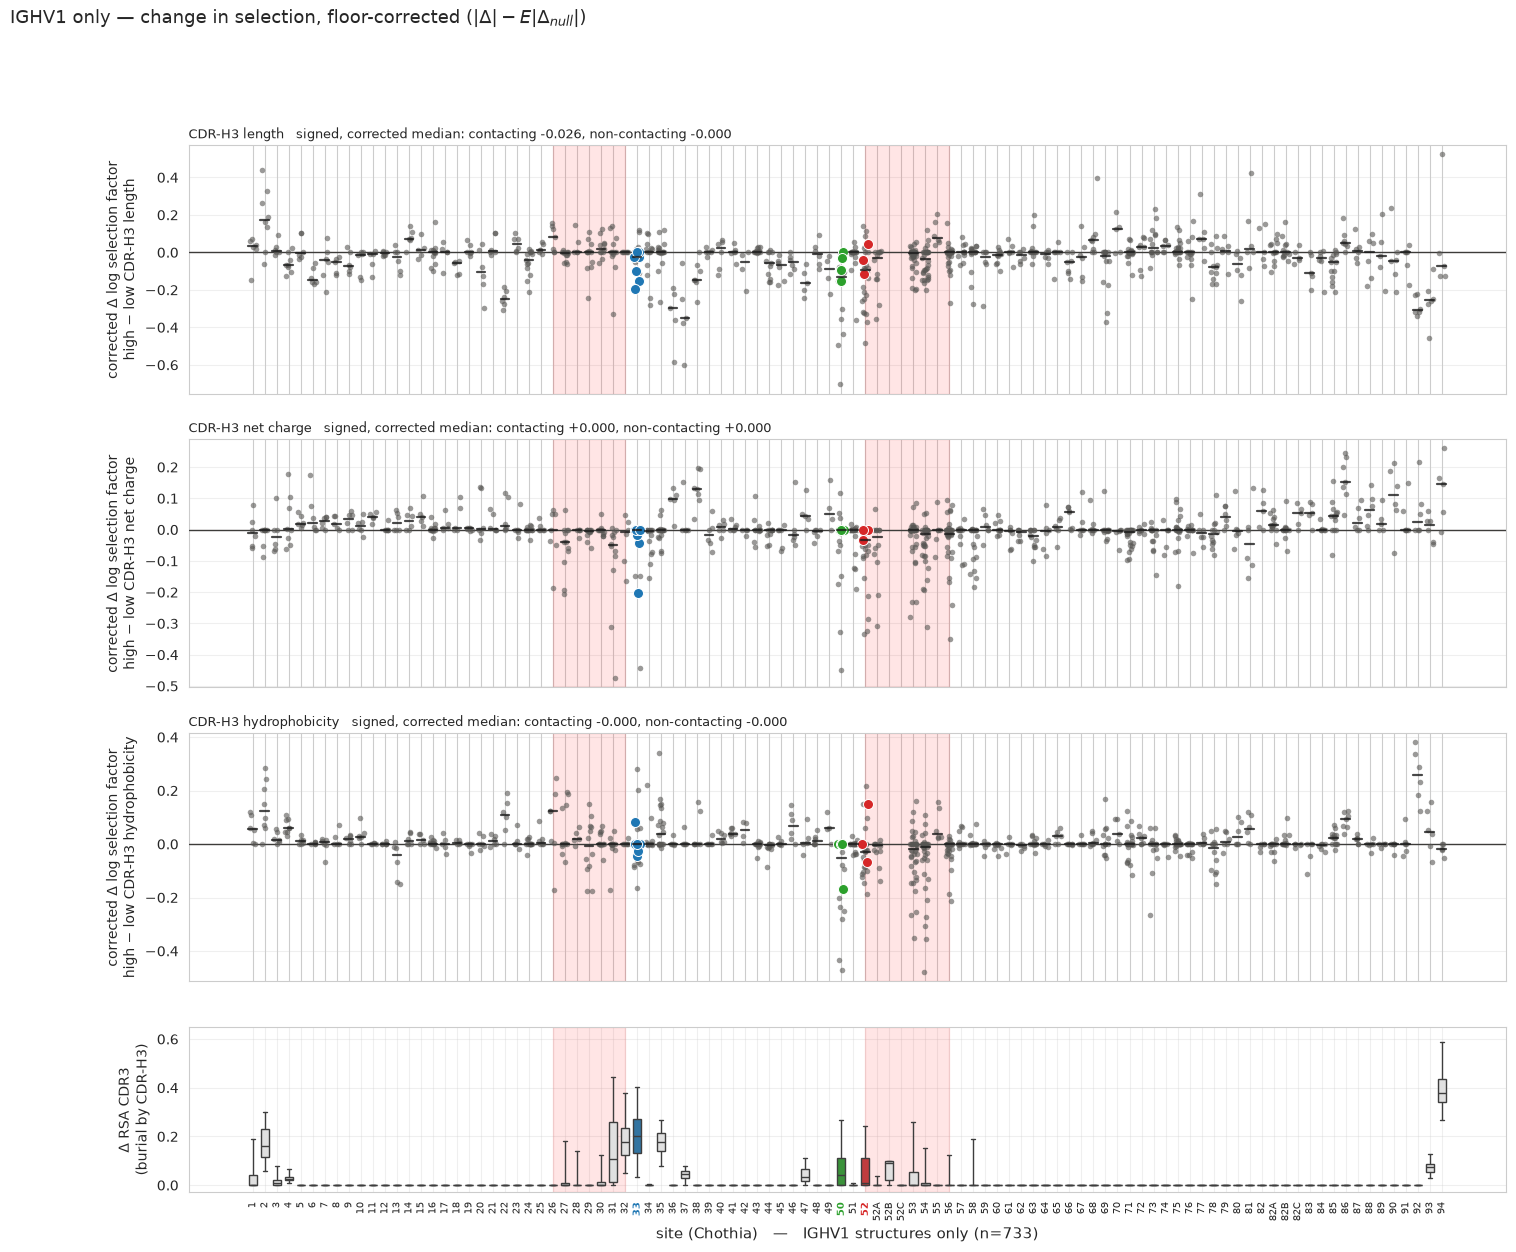

/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


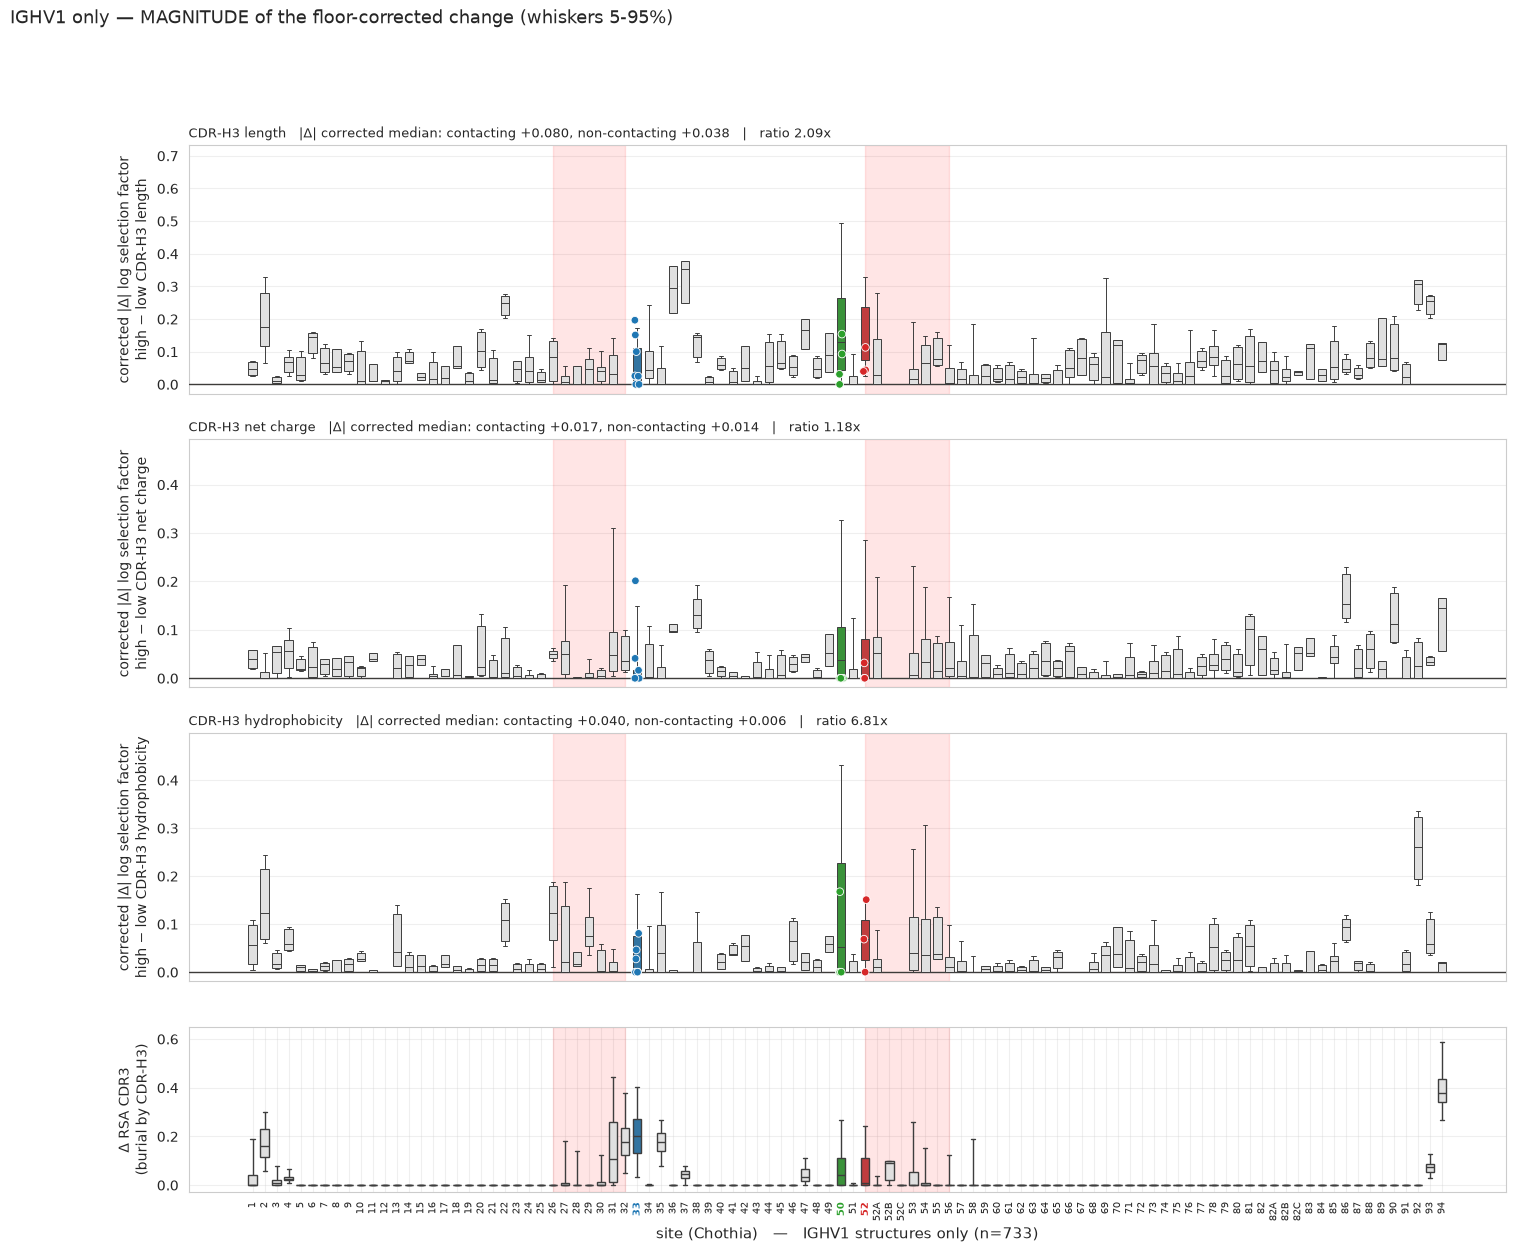

/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


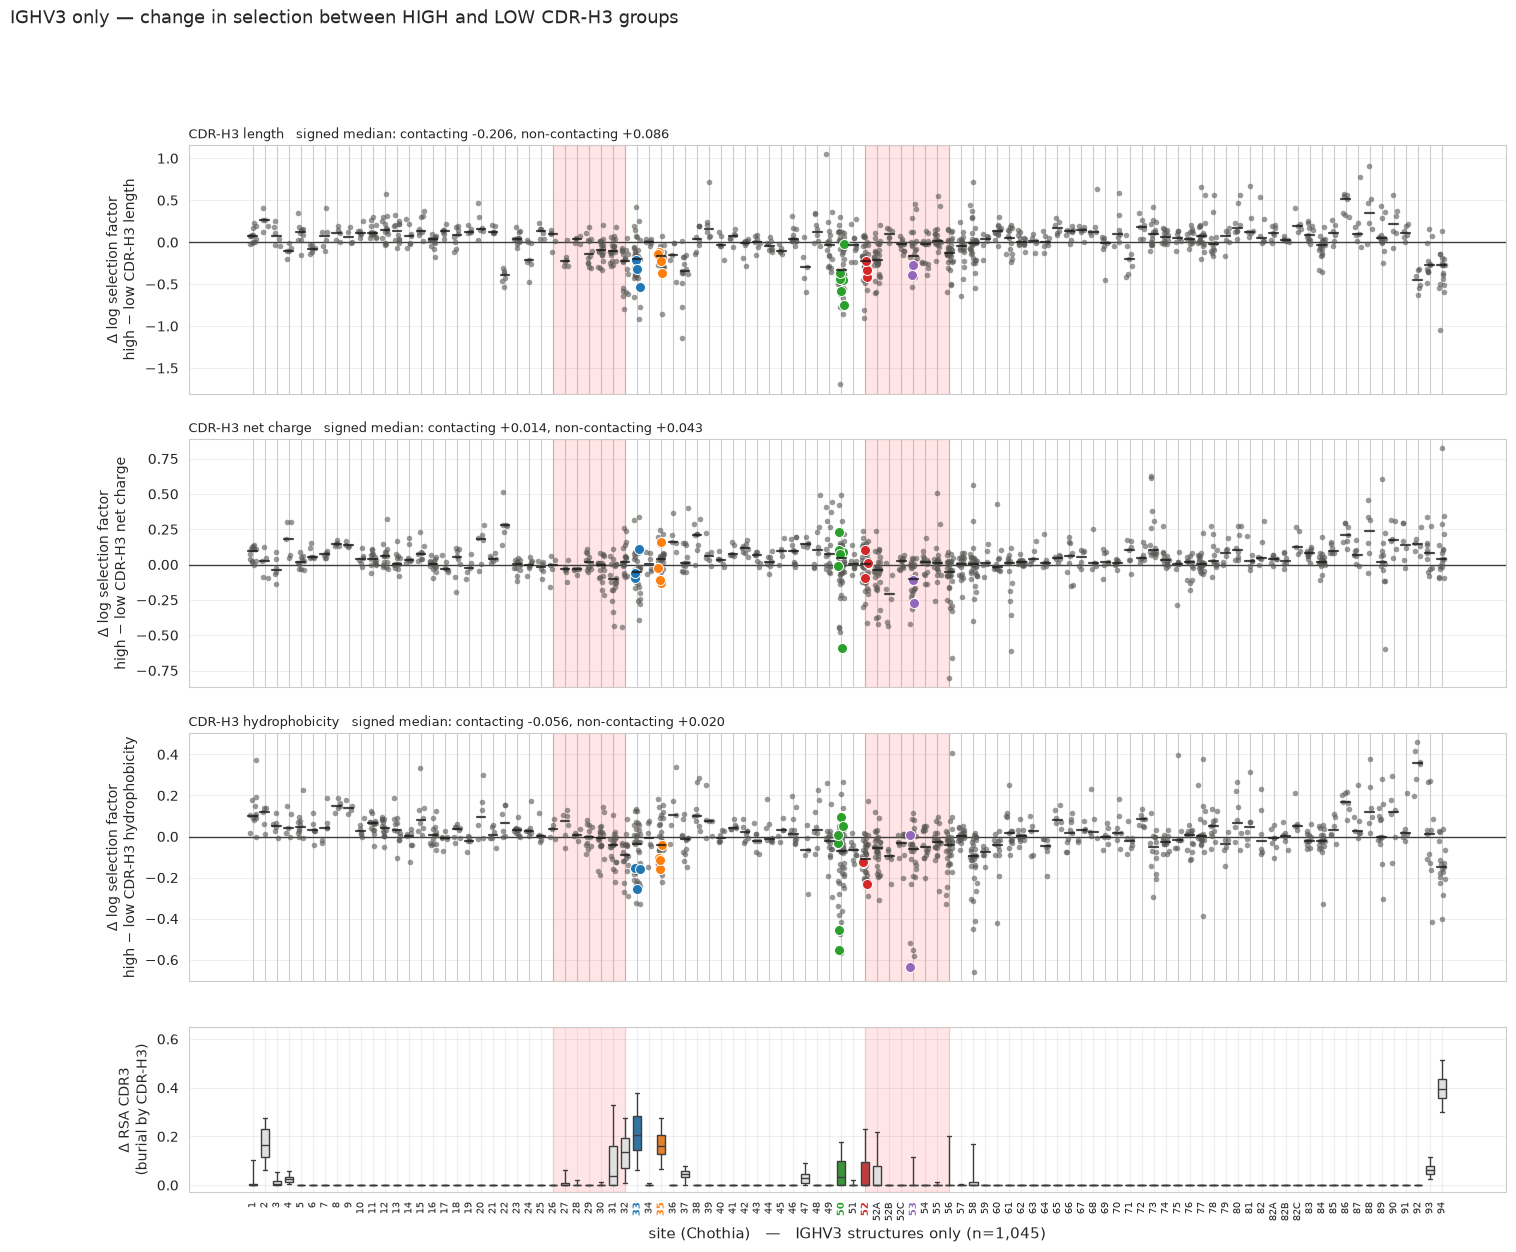

/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


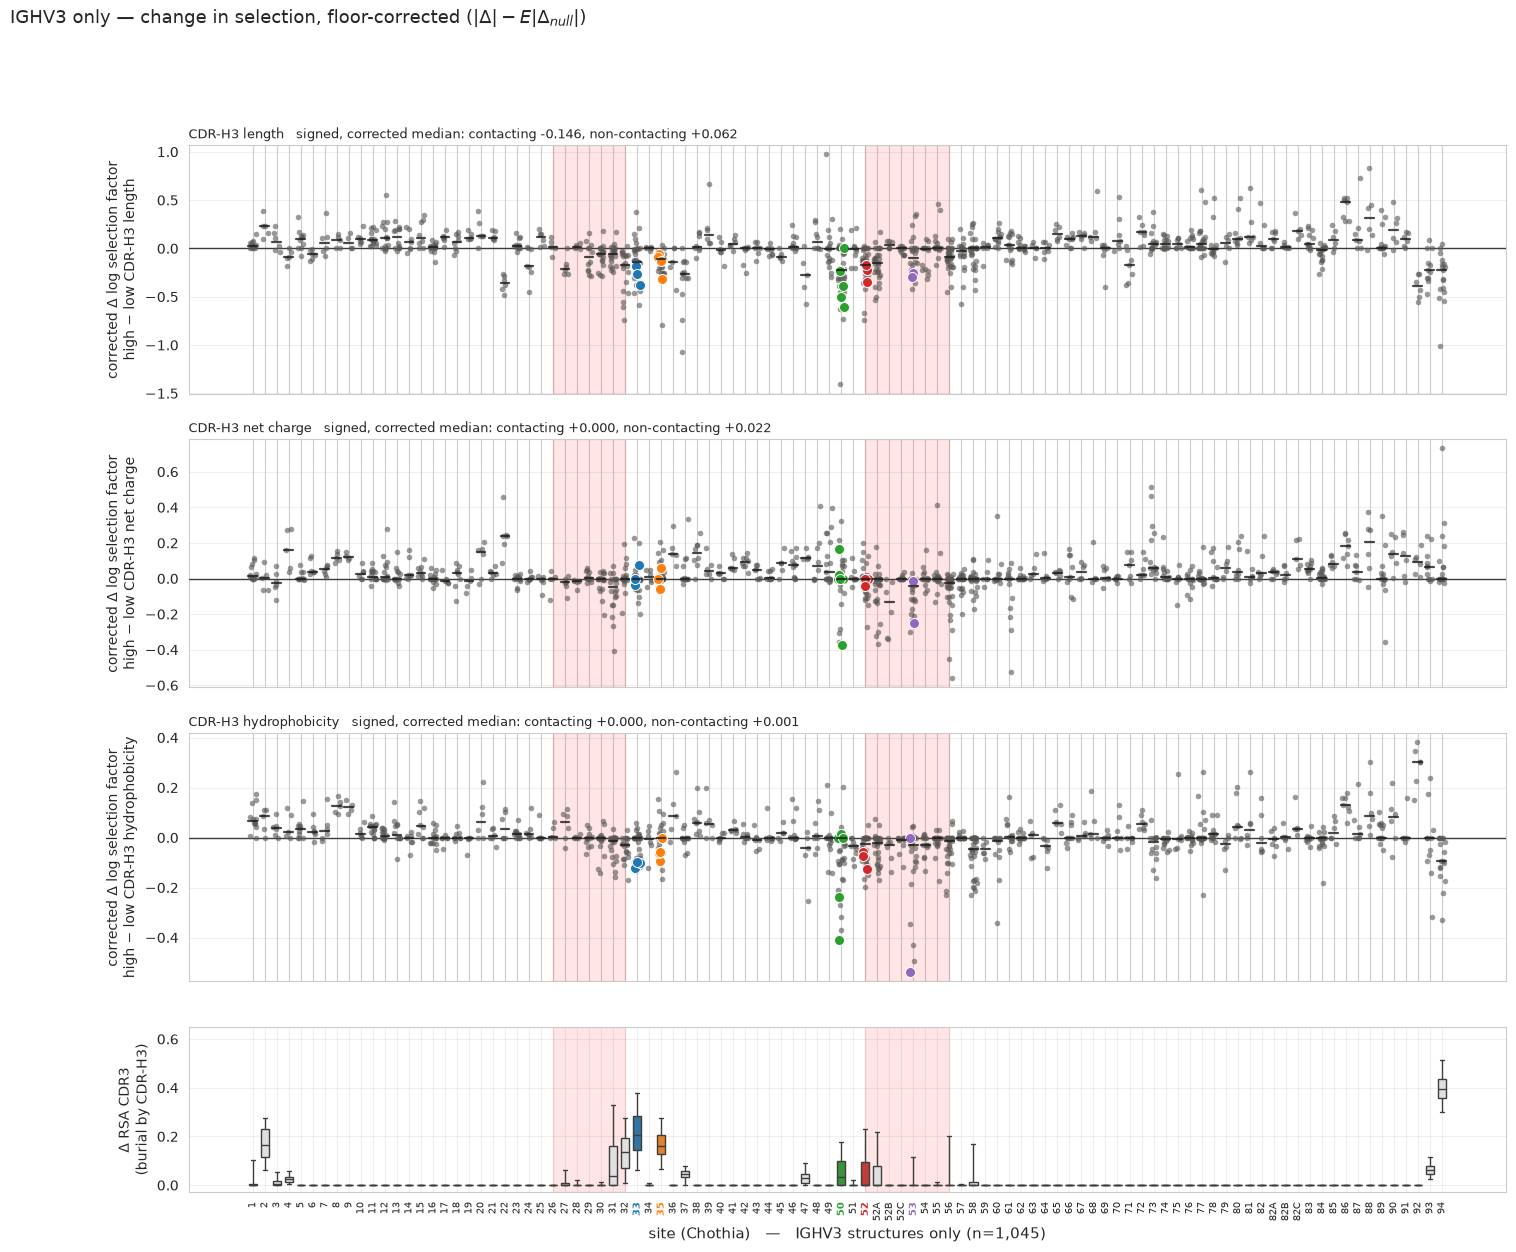

/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/ipykernel_3628388/3893778399.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


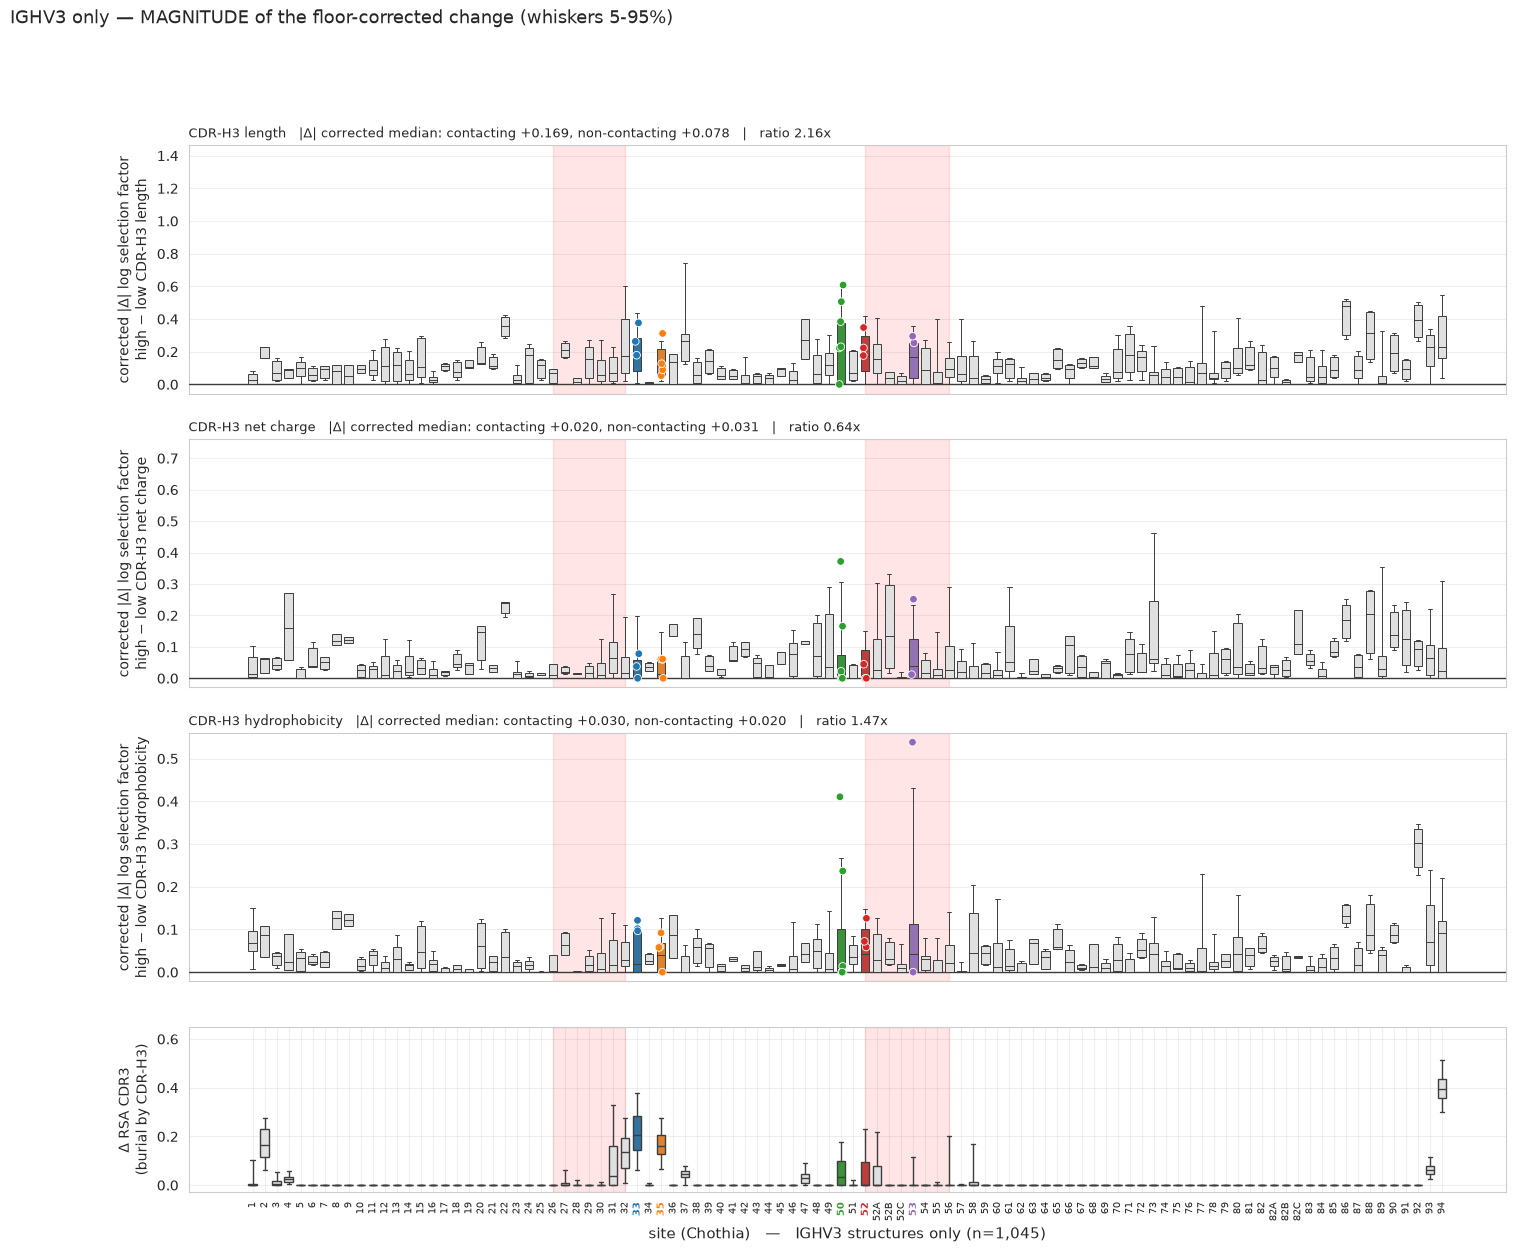

In [10]:
for vf in V_FAMILIES:
    along_v_region("points", f"fig6_along_v_region_{vf}.pdf",
                   f"{vf} only — change in selection between HIGH and LOW CDR-H3 groups",
                   data=split_by_family[vf], v_family=vf)
    # same points after subtracting each substitution's own noise floor: anything that
    # does not clear its floor sits exactly on zero, so the panel is self-calibrating and
    # needs no band
    along_v_region("points", f"fig6_along_v_region_{vf}_corrected.pdf",
                   f"{vf} only — change in selection, floor-corrected "
                   f"($|\\Delta| - E|\\Delta_{{null}}|$)",
                   data=split_by_family[vf], value="delta_corrected",
                   ylab="corrected $\\Delta$ log selection factor", v_family=vf)
    along_v_region("box", f"fig6_along_v_region_{vf}_absolute_corrected.pdf",
                   f"{vf} only — MAGNITUDE of the floor-corrected change "
                   f"(whiskers 5-95%)",
                   data=split_by_family[vf], value="abs_delta_corrected",
                   ylab="corrected |$\\Delta$| log selection factor", v_family=vf)


## 4. Is the shift residue-specific, or does the whole site move?

Entrenchment is a claim about *which* residue is preferred, which predicts a reordering of
targets at a site. A uniform slide of every target is instead a change in the site's overall
constraint. Subtracting the per-(family, site, germline residue) mean separates them.

Concretely, two things could happen at a site as the CDR-H3 lengthens. Every target could
get worse by about the same amount, leaving the site more constrained overall but the
*ranking* of targets unchanged. Or the targets could move differently, so that which
alternative is least bad changes. Only the second is what entrenchment claims, since
entrenchment is a statement about which residue is preferred on which background.
Subtracting the per-(family, site, germline residue) mean removes everything common to all
targets and leaves only the differences between them.

**What this checks.** Whether the CDR-H3 changes *which* residue is preferred at a site, or
only how constrained the whole site is.
**Conclusion.** Almost entirely the latter: ~83% of the shift is movement common to every
target, and once centered, contacting and non-contacting sites are indistinguishable.

**Scope.** This is a statement about the CDR-H3's contribution only. The light chain and the
antigen are absent from DASM's input and cannot be stratified this way, so nothing here
rules out their reordering residue preference at these same sites. The correct reading is
that the CDR-H3 contributes overall constraint rather than residue choice -- not that
entrenchment is non-specific.

In [11]:
d = sub_df.dropna(subset=["cdr3_length", "log_selection_factor"]).copy()
key = ["family_key", "site", "parent_aa"]
d["site_mean"] = d.groupby(key, observed=True).log_selection_factor.transform("mean")
d["centered"] = d.log_selection_factor - d.site_mean
n_t = d.groupby(key, observed=True).log_selection_factor.transform("size")
print(f"targets per (family, site, germline residue): median {n_t.median():.0f}, "
      f"range {n_t.min()}-{n_t.max()} (limited by the one-nucleotide-away filter)")

raw_s = binary_deltas(d, "cdr3_length", null=NULL_POOLED)
cen = d.rename(columns={"log_selection_factor": "_orig", "centered": "log_selection_factor"})
# Centering removes what is common to every target at a (family, site, germline residue),
# which changes the spread the floor is built from, so the centered frame needs its own
# null rather than the pooled one.
cen_s = binary_deltas(cen, "cdr3_length", null=null_abs_delta(cen))
rows = []
for lbl, x in [("RAW", raw_s), ("CENTERED", cen_s)]:
    for g, sel in [("entrenched", x.entrenched),
                   ("contacting others", (~x.entrenched) & (x.contact_class == "contacting")),
                   ("non-contacting", (~x.entrenched) & (x.contact_class == "non-contacting"))]:
        rows.append({"form": lbl, **{k: v for k, v in sign_summary(x[sel], g).items()}})
decomp = pd.DataFrame(rows)
decomp.to_csv(f"{OUTPUT_DIR}/centering_decomposition.csv", index=False)
print(decomp[["form", "group", "n", "pct_down", "median_delta", "median_abs"]]
      .round(4).to_string(index=False))
e_raw = raw_s[raw_s.entrenched].delta.median(); e_cen = cen_s[cen_s.entrenched].delta.median()
print(f"\nentrenched median delta: raw {e_raw:+.3f} -> centered {e_cen:+.3f}   "
      f"({100*(1-abs(e_cen/e_raw)):.0f}% of the shift is site-level scaling)")

targets per (family, site, germline residue): median 6, range 4-7 (limited by the one-nucleotide-away filter)


    form             group   n  pct_down  median_delta  median_abs
     RAW        entrenched  29   93.1034       -0.2215      0.1558
     RAW contacting others 273   76.1905       -0.1673      0.1336
     RAW    non-contacting 595   36.1345        0.0394      0.0629
CENTERED        entrenched  29   68.9655       -0.0379      0.0187
CENTERED contacting others 273   49.8168        0.0011      0.0601
CENTERED    non-contacting 595   52.2689       -0.0030      0.0432

entrenched median delta: raw -0.222 -> centered -0.038   (83% of the shift is site-level scaling)


### Figure 5 --- parallel or crossing?

The same point as a picture. For each entrenched site, the median log selection factor of
every reachable target, in the short-CDR-H3 half and the long-CDR-H3 half. Lines that stay
parallel mean the whole site shifted and the ranking is intact; lines that cross or fan mean
the CDR-H3 changed which target is preferred.

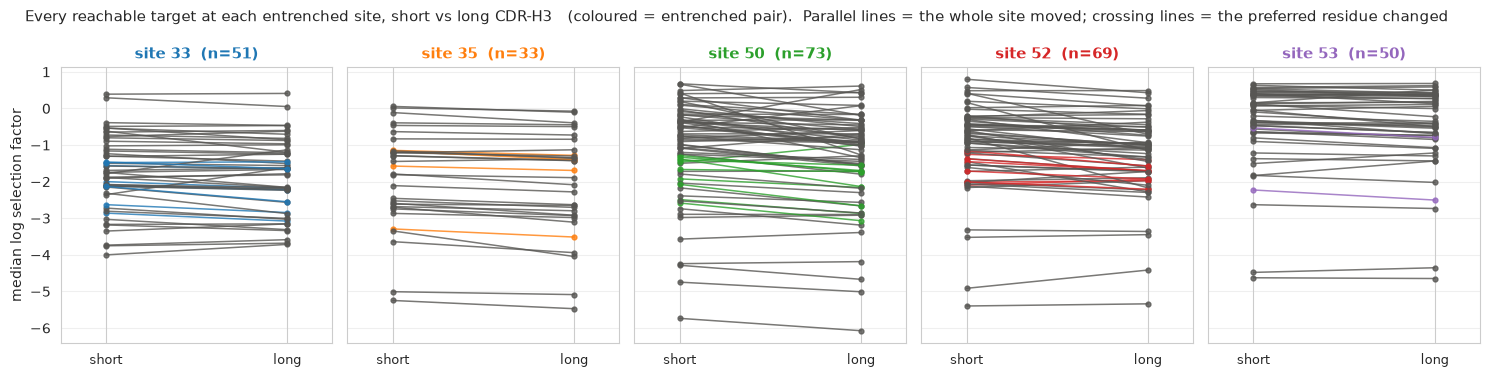

In [12]:
binned = assign_hi_lo(sub_df, "cdr3_length")
fig, axes = plt.subplots(1, len(ENT_SITES), figsize=(15, 3.8), sharey=True)
for ax, site in zip(np.atleast_1d(axes), ENT_SITES):
    d = binned[binned.site == site]
    m = d.groupby(["parent_aa", "selection_factor_target_aa", "hi"],
                  observed=True).log_selection_factor.median().unstack()
    m = m.dropna()
    for (aa, tgt), row in m.iterrows():
        ax.plot([0, 1], [row[0], row[1]], "-o", ms=3.5, lw=1.1, alpha=0.8,
                color=ENTRENCHED_SITE_COLORS.get(site, BLUE)
                if (site, aa, tgt) in WITHIN_PAIRS else GREY_DOT)
    ax.set_xlim(-0.25, 1.25); ax.set_xticks([0, 1])
    ax.set_xticklabels(["short", "long"], fontsize=9)
    ax.set_title(f"site {site}  (n={len(m)})", fontsize=10.5, fontweight="bold",
                 color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
    ax.grid(True, axis="y", alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("median log selection factor", fontsize=10)
fig.suptitle("Every reachable target at each entrenched site, short vs long CDR-H3   "
             "(coloured = entrenched pair).  Parallel lines = the whole site moved; "
             "crossing lines = the preferred residue changed", fontsize=11, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig5_interaction_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 5. Does a long CDR-H3 just lower everything?

A trivial alternative to the contact story: longer CDR-H3s might simply drag DASM's output
down across the whole V region, in which case the shift at contacted sites would be a global
offset rather than anything structural.

**What this checks.** Whether CDR-H3 length moves the V-region mean, against how far it
moves the individual contact classes.
**Conclusion.** It does not. The per-family V-region mean is essentially flat in CDR-H3
length, while the class shifts are an order of magnitude larger and opposite in sign. The
response is redistribution, so the claim throughout is relative rather than absolute.

Note the near-cancellation of the total is arithmetic, not evidence: the count-weighted class
shifts sum to the global shift by construction, so their agreement says nothing. Nor does the
cancellation generalise -- it is close in IGHV3 and absent in IGHV1, which is why no claim
rests on it.


In [13]:
base = sub_df.dropna(subset=["cdr3_length", "log_selection_factor"]).join(
    classified[["cdr3_contact_freq"]], on="site")
base["contact"] = base.cdr3_contact_freq.fillna(0)
base["cls"] = np.where(base.contact > 0.5, "contacting",
                np.where(base.contact > 0, "occasional", "non-contacting"))

# The family is the unit: one V-region mean per family, against that family's CDR-H3.
fam_glob = base.groupby("family_key").agg(glob=("log_selection_factor", "mean"),
                                          L=("cdr3_length", "first"))
rho, p = spearmanr(fam_glob.L, fam_glob.glob)
t3 = fam_glob.assign(t=pd.qcut(fam_glob.L, 3, labels=["short", "mid", "long"])
                     ).groupby("t", observed=True).glob.mean()
print(f"V-region mean log SF vs CDR-H3 length: rho={rho:+.4f} (p={p:.1e})")
print(f"  short {t3['short']:.4f}  mid {t3['mid']:.4f}  long {t3['long']:.4f}"
      f"   long - short = {t3['long'] - t3['short']:+.4f}")

# ...against the shift within each contact class, on the same tertile split
cls_shift = []
for cls, g in base.groupby("cls"):
    f = g.groupby("family_key").log_selection_factor.mean().to_frame("v").join(
        fam_glob[["L"]])
    tt = f.assign(t=pd.qcut(f.L, 3, labels=["short", "mid", "long"])
                  ).groupby("t", observed=True).v.mean()
    cls_shift.append({"class": cls, "n_rows": len(g),
                      "long_minus_short": tt["long"] - tt["short"]})
print("\nby contact class:")
print(pd.DataFrame(cls_shift).round(4).to_string(index=False))
print("\n-> the global shift is an order of magnitude smaller than the class shifts,")
print("   which are opposite in sign: redistribution, not a global offset.")


V-region mean log SF vs CDR-H3 length: rho=+0.0783 (p=2.4e-08)
  short -1.9366  mid -1.9064  long -1.9174   long - short = +0.0192



by contact class:
         class  n_rows  long_minus_short
    contacting  289980           -0.2165
non-contacting 1280568            0.1556
    occasional  904050           -0.1005

-> the global shift is an order of magnitude smaller than the class shifts,
   which are opposite in sign: redistribution, not a global offset.


## 6. Nuisance variables, and whether entrenchment adds anything

`n_subs`, the number of substitutions at a site, is a real nuisance variable: entrenched
sites are the busiest in the dataset because entrenchment requires germline diversity, which
generates substitution units.

**What this checks.** Whether the contact relationship survives the two site-level covariates
that track it, and whether entrenchment adds anything of its own.
**Conclusion.** Contact survives (beta=-13.2, p=2e-06). Substitution count is a real
secondary effect. The entrenched indicator falls from p=0.002 alone to p=0.62 once contact
and substitution count are included.

In [14]:
per_site = LEN.groupby("site").agg(
    shift=("delta", "median"), abs_shift=("abs_delta_corrected", "median"), n_subs=("delta", "size"),
    n_fam=("n_families", "median"), iqr=("iqr", "median")).join(
    classified[["cdr3_contact_freq"]]).dropna()
per_site = per_site[per_site.n_subs >= 5]
per_site["ent"] = per_site.index.isin(ENT_SITES).astype(float)
per_site.to_csv(f"{OUTPUT_DIR}/per_site_shift.csv")
print(f"{len(per_site)} sites.  entrenched n_subs: "
      + ", ".join(f"{i}={int(r.n_subs)}" for i, r in per_site[per_site.ent == 1].iterrows())
      + f"   |  median elsewhere = {per_site[per_site.ent==0].n_subs.median():.0f}")
print("\nmarginal Spearman vs per-site shift:")
for c in ["cdr3_contact_freq", "n_subs", "n_fam", "iqr"]:
    rr, pp = spearmanr(per_site[c], per_site["shift"])
    print(f"  {c:20s} rho={rr:+.3f}  p={pp:.2e}")


def rank_ols(y, cols, label):
    X = pd.DataFrame({c: (per_site[c].rank() if c != "ent" else per_site[c]) for c in cols})
    X = (X - X.mean()) / X.std(ddof=0); X.insert(0, "const", 1.0)
    m = OLS(np.asarray(per_site[y].rank(), float), np.asarray(X, float)).fit()
    terms = "   ".join(f"{n}: b={b:+.2f} p={p:.1e}"
                       for n, b, p in zip(X.columns, m.params, m.pvalues) if n != "const")
    print(f"  {label:34s} R2={m.rsquared:.3f}   {terms}")


print("\nrank regressions on the per-site signed shift:")
rank_ols("shift", ["ent"], "~ entrenched")
rank_ols("shift", ["ent", "cdr3_contact_freq"], "~ entrenched + contact")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs"], "~ entrenched + contact + n_subs")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs", "n_fam"], "~ + n_fam")

100 sites.  entrenched n_subs: 33=42, 35=27, 50=63, 52=53, 53=45   |  median elsewhere = 12

marginal Spearman vs per-site shift:
  cdr3_contact_freq    rho=-0.533  p=1.10e-08
  n_subs               rho=-0.405  p=2.96e-05
  n_fam                rho=+0.367  p=1.75e-04
  iqr                  rho=+0.038  p=7.06e-01

rank regressions on the per-site signed shift:
  ~ entrenched                       R2=0.095   ent: b=-8.88 p=1.9e-03
  ~ entrenched + contact             R2=0.302   ent: b=-4.03 p=1.3e-01   cdr3_contact_freq: b=-14.00 p=5.5e-07
  ~ entrenched + contact + n_subs    R2=0.368   ent: b=-1.42 p=5.9e-01   cdr3_contact_freq: b=-12.99 p=1.3e-06   n_subs: b=-8.07 p=2.0e-03
  ~ + n_fam                          R2=0.369   ent: b=-1.32 p=6.2e-01   cdr3_contact_freq: b=-13.19 p=1.8e-06   n_subs: b=-9.31 p=3.5e-02   n_fam: b=-1.51 p=7.3e-01


In [15]:
# The germline-codon filter is applied per site, so it could in principle select families
# non-randomly by CDR-H3 length. It does not: the shift is uniform across the V region
# and unrelated to the per-site result.
gl = aa_v.drop_duplicates(["pcp_index", "site"])[["pcp_index", "site", "is_germline_codon"]]
gl = gl.merge(pcp_df[["pcp_index", "family_key", "cdr3_length"]], on="pcp_index")
gl = gl.drop_duplicates(["family_key", "site"]).dropna(subset=["cdr3_length"])
gl["tert"] = pd.qcut(gl.cdr3_length, 3, labels=["short", "mid", "long"])
ret = gl.pivot_table(index="site", columns="tert", values="is_germline_codon",
                     aggfunc="mean", observed=True)
ret["delta_ret"] = ret["long"] - ret["short"]
ret = ret.join(classified[["cdr3_contact_freq"]]).dropna()
print("germline-state retention (parent still carries the germline codon):")
print(f"  overall  short {gl[gl.tert=='short'].is_germline_codon.mean():.3f}   "
      f"mid {gl[gl.tert=='mid'].is_germline_codon.mean():.3f}   "
      f"long {gl[gl.tert=='long'].is_germline_codon.mean():.3f}")
rr, pp = spearmanr(ret.cdr3_contact_freq, ret.delta_ret)
print(f"  retention change vs contact frequency: rho={rr:+.3f} p={pp:.2f}")
j = ret.join(per_site[["shift"]]).dropna()
rr, pp = spearmanr(j.delta_ret, j["shift"])
print(f"  retention change vs per-site shift:    rho={rr:+.3f} p={pp:.2f}")
print("-> the per-site germline filter does not drive the contact result.")

germline-state retention (parent still carries the germline codon):
  overall  short 0.880   mid 0.859   long 0.853
  retention change vs contact frequency: rho=-0.096 p=0.34
  retention change vs per-site shift:    rho=+0.089 p=0.38
-> the per-site germline filter does not drive the contact result.


### 6a. Is it germline diversity rather than contact?

`n_subs` above is one face of germline diversity; the number of germline amino acids at
the site is the other and the more direct one. Entrenched and CDR-H3-contacting sites are
also the germline-diverse sites, so "contacting sites are more CDR-H3-sensitive" and
"germline-diverse sites are more CDR-H3-sensitive" are hard to tell apart marginally.

Diversity is measured from the germline assignment of every clonal family, not from the
residues that clear `MIN_FAMILIES`: the latter would bake the unit threshold into the
covariate and make it a restatement of `n_subs`. Monomorphic sites are excluded, having
no diversity to stratify on. Both a count and an entropy binning are reported, since the
count ignores how skewed the residue distribution is.

Diversity is measured from the germline assignment of every clonal family, and the
magnitude used here is the floor-corrected one from Section 2a -- germline diversity
tracks how finely families split across germline residues, and so tracks the family
counts that set the noise floor, which is exactly the thing the correction removes.

**What this checks.** First, whether germline diversity is even capable of confounding
this -- it would have to be higher at contacting sites *and* positively related to the
corrected magnitude. Second, whether the contact effect survives within each level of
diversity.
**Conclusion.** It cannot confound it: diversity is higher at contacting sites on the
residue count but its relation to the corrected magnitude is negative, so it works
against the contrast rather than creating it. The contact effect then holds within every
diversity bin; per-bin ratios are annotated on the figure.

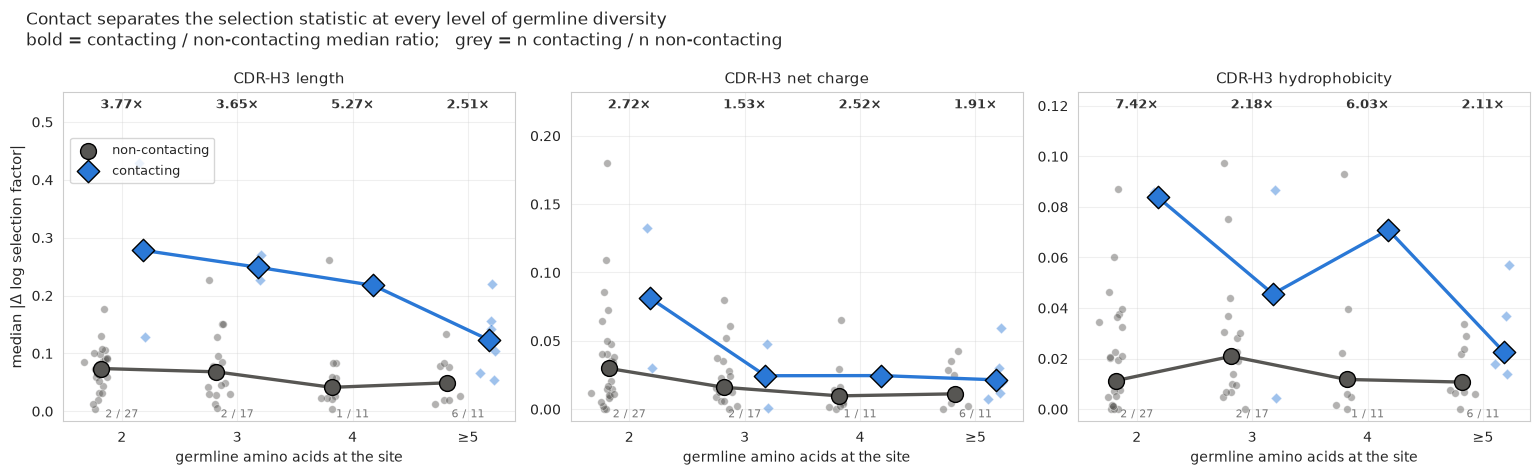

23 monomorphic sites excluded; 77 sites retained

  k        contacting 5.00 vs rest 3.00  (higher at contacting sites, p=0.02);  rho(k, |delta|) = -0.09
  entropy  contacting 0.72 vs rest 0.62  (higher at contacting sites, p=0.51);  rho(entropy, |delta|) = -0.18

-> diversity is higher at contacting sites on the count but not on entropy, and its
   relation to the corrected magnitude is negative for both (rho -0.18 to -0.09):
   more diverse sites move LESS, so diversity can only understate the contrast,
   not create it. The stratification below shows it directly.

bin                             2     3     4    Q1    Q2    Q3    Q4    ≥5
descriptor          binning                                                
cdr3_charge         entropy   NaN   NaN   NaN  1.94  2.23  1.96  1.03   NaN
                    k        2.72  1.53  2.52   NaN   NaN   NaN   NaN  1.91
cdr3_hydrophobicity entropy   NaN   NaN   NaN  4.00  4.83  4.34  2.00   NaN
                    k        7.42  2.18  6.03 

In [16]:
# Germline diversity per site, from the germline assignment of every clonal family in the
# analysis. Deliberately independent of the analysis filters: counting only residues that
# clear MIN_FAMILIES would bake the unit threshold into the covariate and make it close to
# n_subs, which the previous section already controls.
_germ = pd.read_csv(f"germline/germline_codons_{NUMBERING}.csv", dtype={"site": str})
_fam_v = sub_df.drop_duplicates("family_key")[["family_key", "v_gene"]]
_per_family = _germ[_germ.site.isin(set(split.site))].merge(_fam_v, on="v_gene")


def _entropy(x):
    p = x.value_counts(normalize=True)
    return float(-(p * np.log(p)).sum())


diversity = _per_family.groupby("site").amino_acid.agg(
    k="nunique", entropy=_entropy)

# Monomorphic sites carry a single germline amino acid, so they have no germline
# diversity to stratify on and cannot inform this comparison. They are dropped rather
# than folded into the lowest bin -- doing the latter puts sites 3 and 4, the unexplained
# N-terminal pair noted in the caveats, into a bin they do not belong in.
n_mono = int((diversity.k == 1).sum())
K_ORDER = ["2", "3", "4", "≥5"]

fig, axes = plt.subplots(1, len(cu.CDR3_DESCRIPTORS), figsize=(15.5, 4.8))
ratio_rows = []
for ax, desc in zip(axes, cu.CDR3_DESCRIPTORS):
    g = (split[split.descriptor == desc]
         .groupby("site").agg(y=("abs_delta_corrected", "median"), n_subs=("delta", "size"),
                              contact=("contact", "first"))
         .join(diversity))
    g = g[(g.n_subs >= 5) & (g.k >= 2)].copy()
    g["c"] = g.contact > 0.5
    g["kb"] = pd.cut(g.k, [1, 2, 3, 4, np.inf], labels=K_ORDER)
    g["eq"] = pd.qcut(g.entropy, 4, labels=["Q1", "Q2", "Q3", "Q4"])

    for lab, mask, colour, mk in [("non-contacting", ~g.c, GREY_DOT, "o"),
                                  ("contacting", g.c, BLUE, "D")]:
        sub, off = g[mask], (0.18 if lab == "contacting" else -0.18)
        xs = np.array([K_ORDER.index(str(b)) for b in sub.kb]) + off
        ax.scatter(xs + np.random.default_rng(1).normal(0, 0.055, len(xs)), sub.y,
                   s=30, c=colour, marker=mk, alpha=0.45, edgecolor="white", lw=0.5,
                   zorder=2)
        med = sub.groupby("kb", observed=True).y.median().reindex(K_ORDER)
        xm = [K_ORDER.index(b) + off for b in K_ORDER]
        ax.plot(xm, med.values, "-", color=colour, lw=2.4, zorder=3)
        ax.scatter(xm, med.values, s=130, c=colour, marker=mk, edgecolor="black",
                   lw=1.0, zorder=4, label=lab)

    for bincol, binname, order in [("kb", "k", K_ORDER),
                                   ("eq", "entropy", ["Q1", "Q2", "Q3", "Q4"])]:
        t = g.pivot_table(index=bincol, columns="c", values="y", aggfunc="median",
                          observed=True)
        n = g.groupby(bincol, observed=True).c.agg(["sum", "size"]).reindex(order)
        for b in order:
            ratio_rows.append({
                "descriptor": desc, "binning": binname, "bin": b,
                "ratio": t.loc[b, True] / t.loc[b, False],
                "n_contacting": int(n.loc[b, "sum"]),
                "n_rest": int(n.loc[b, "size"] - n.loc[b, "sum"])})

    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.22 * (hi - lo))
    kt = g.pivot_table(index="kb", columns="c", values="y", aggfunc="median",
                       observed=True)
    kn = g.groupby("kb", observed=True).c.agg(["sum", "size"]).reindex(K_ORDER)
    for i, b in enumerate(K_ORDER):
        ax.annotate(f"{kt.loc[b, True] / kt.loc[b, False]:.2f}×",
                    (i, ax.get_ylim()[1]), xytext=(0, -12), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", color="#333")
        ax.annotate(f"{int(kn.loc[b, 'sum'])} / {int(kn.loc[b, 'size'] - kn.loc[b, 'sum'])}",
                    (i, lo), xytext=(0, 3), textcoords="offset points", ha="center",
                    fontsize=8, color="#777")
    ax.set_xticks(range(len(K_ORDER)))
    ax.set_xticklabels(K_ORDER)
    ax.set_xlabel("germline amino acids at the site", fontsize=10)
    ax.set_title(LAB[desc], fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("median |$\\Delta$ log selection factor|", fontsize=10.5)
axes[0].legend(fontsize=9.5, loc="upper left", bbox_to_anchor=(0.0, 0.88))
fig.suptitle("Contact separates the selection statistic at every level of germline "
             "diversity\nbold = contacting / non-contacting median ratio;   "
             "grey = n contacting / n non-contacting", fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig_selection_by_k.pdf", dpi=300, bbox_inches="tight")
plt.show()

by_div = pd.DataFrame(ratio_rows)
by_div.to_csv(f"{OUTPUT_DIR}/contact_ratio_by_diversity.csv", index=False)

# Whether diversity could confound this at all: it would have to be higher at contacting
# sites AND positively related to |delta|. Both are checked here.
D = (split[split.descriptor == "cdr3_length"]
     .groupby("site").agg(y=("abs_delta_corrected", "median"), n_subs=("delta", "size"),
                          contact=("contact", "first")).join(diversity))
D = D[(D.n_subs >= 5) & (D.k >= 2)]
D["c"] = D.contact > 0.5
print(f"{n_mono} monomorphic sites excluded; {len(D)} sites retained\n")
# To confound, diversity must be (a) higher at contacting sites AND (b) positively
# related to |delta|. Report both and let the numbers state which leg fails.
rhos = {}
for col in ["k", "entropy"]:
    mw = mannwhitneyu(D.loc[D.c, col], D.loc[~D.c, col]).pvalue
    rhos[col] = spearmanr(D[col], D.y)[0]
    higher = "higher" if D.loc[D.c, col].median() > D.loc[~D.c, col].median() else "lower"
    print(f"  {col:8s} contacting {D.loc[D.c, col].median():.2f} vs rest "
          f"{D.loc[~D.c, col].median():.2f}  ({higher} at contacting sites, p={mw:.2f});"
          f"  rho({col}, |delta|) = {rhos[col]:+.2f}")
# Leg (b) is directional: to inflate the contact contrast diversity must be
# POSITIVELY related to the magnitude. A negative relation works against the contrast
# instead, so it cannot manufacture it.
inflates = [c for c in rhos if rhos[c] > 0
            and D.loc[D.c, c].median() > D.loc[~D.c, c].median()]
print(f"\n-> diversity is higher at contacting sites on the count but not on entropy, "
      f"and its\n   relation to the corrected magnitude is negative for both "
      f"(rho {min(rhos.values()):+.2f} to {max(rhos.values()):+.2f}):")
if inflates:
    raise ValueError(f"diversity could inflate the contact contrast via {inflates}; "
                     "the stratification below is then required, not confirmatory")
print("   more diverse sites move LESS, so diversity can only understate the contrast,")
print("   not create it. The stratification below shows it directly.\n")
print(by_div.pivot_table(index=["descriptor", "binning"], columns="bin",
                         values="ratio").round(2).to_string())
print(f"\ncontact ratio above 1 in {(by_div.ratio > 1).sum()} of {len(by_div)} "
      f"(descriptor x binning x bin) cells")

## 7. Model-free: does a longer CDR-H3 actually bury these sites more?

No DASM here. For each SAbDab structure we take its own CDR-H3 length (residues in the
95--102 window) and ask whether burial at each V-region site rises with it. RSA has no
normalisation across residues, so the compositional caveats of Sections 4--5 do not apply.

**What this checks.** Whether a longer CDR-H3 physically buries these sites more, using
crystal structures alone.
**Conclusion.** Yes, and this is the strongest result here: burial rises with the structure's
own CDR-H3 length at all five entrenched sites (rho 0.21-0.46, all p<1e-10) against ~+0.05
elsewhere. It gives the DASM result an independent structural basis.

In [17]:
# CDR-H3 length per structure = residues in the 95-102 window, from the UNFILTERED frame
_n = sa_all.assign(n=sa_all.site.map(cu.site_number))
cdr3_len = _n[(_n.n >= 95) & (_n.n <= 102)].groupby("pdb_id").size().rename("cdr3_len")
assert len(cdr3_len) > 0, "no structures with residues in the 95-102 window"
print(f"{len(cdr3_len):,} structures; CDR-H3 length median {cdr3_len.median():.0f}, "
      f"range {cdr3_len.min()}-{cdr3_len.max()}")
sv = sa_b.join(cdr3_len, on="pdb_id").dropna(subset=["cdr3_len"])

rows = []
for site, g in sv.groupby("site"):
    if g.pdb_id.nunique() < 30 or g.burial_by_vdj_junction.nunique() < 2:
        continue                      # constant burial -> correlation undefined
    rho, pv = spearmanr(g.cdr3_len, g.burial_by_vdj_junction)
    lo = g[g.cdr3_len <= g.cdr3_len.quantile(1/3)]
    hi = g[g.cdr3_len >= g.cdr3_len.quantile(2/3)]
    rows.append({"site": site, "n_struct": g.pdb_id.nunique(), "rho": rho, "p": pv,
                 "burial_short": lo.burial_by_vdj_junction.mean(),
                 "burial_long": hi.burial_by_vdj_junction.mean(),
                 "d_burial": hi.burial_by_vdj_junction.mean()
                             - lo.burial_by_vdj_junction.mean()})
struct = pd.DataFrame(rows).set_index("site")
struct["entrenched"] = struct.index.isin(ENT_SITES)
struct.to_csv(f"{OUTPUT_DIR}/structural_burial_vs_cdr3_length.csv")
print("\nentrenched sites:")
print(struct[struct.entrenched][["n_struct", "rho", "p", "burial_short", "burial_long",
                                 "d_burial"]].round(4).to_string())
print(f"\n{len(struct)} sites with defined rho: median {struct.rho.median():+.3f}; "
      f"entrenched {struct[struct.entrenched].rho.median():+.3f} vs others "
      f"{struct[~struct.entrenched].rho.median():+.3f}  (MW p="
      f"{mannwhitneyu(struct[struct.entrenched].d_burial, struct[~struct.entrenched].d_burial, alternative='greater').pvalue:.4f})")
print("\ntop 10 sites by rho:")
print(struct.nlargest(10, "rho")[["n_struct", "rho", "d_burial", "entrenched"]]
      .round(4).to_string())

1,778 structures; CDR-H3 length median 13, range 2-31

entrenched sites:
      n_struct     rho    p  burial_short  burial_long  d_burial
site                                                            
33        1775  0.3712  0.0        0.1718       0.2462    0.0744
35        1778  0.2208  0.0        0.1570       0.1821    0.0251
50        1778  0.2108  0.0        0.0481       0.0836    0.0355
52        1771  0.4142  0.0        0.0289       0.0921    0.0631
53        1776  0.4556  0.0        0.0045       0.0628    0.0583

52 sites with defined rho: median +0.068; entrenched +0.371 vs others +0.045  (MW p=0.0004)

top 10 sites by rho:
      n_struct     rho  d_burial  entrenched
site                                        
31        1769  0.5125    0.1253       False
53        1776  0.4556    0.0583        True
52        1771  0.4142    0.0631        True
33        1775  0.3712    0.0744        True
32        1775  0.3698    0.0644       False
31A         40  0.3490    0.0889       Fal

DASM per-site shift vs structural rho: -0.320 p=2.20e-02 (n=51)
structural rho vs contact frequency:   +0.431 p=1.61e-03
(the two structural measures are correlated, so they cannot be separated here)


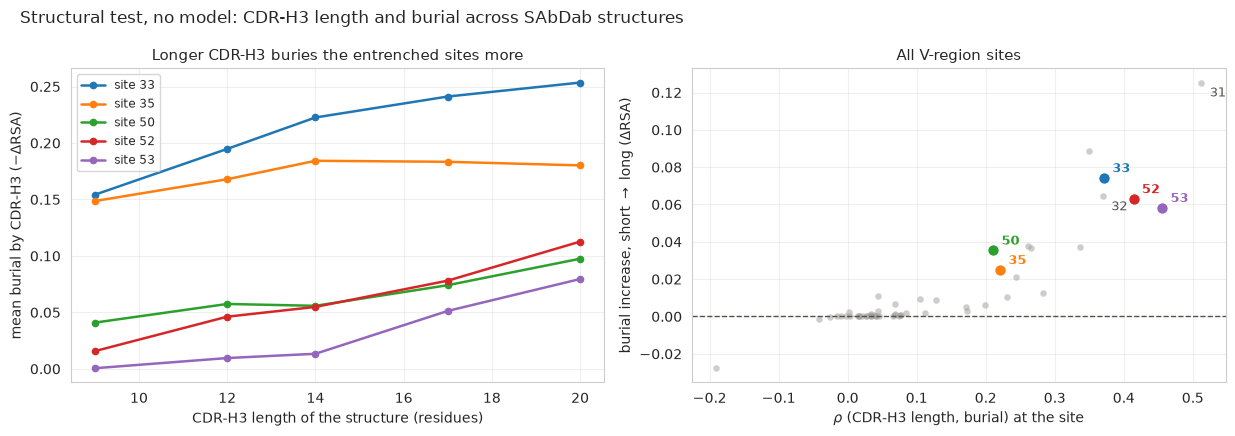

In [18]:
coh = per_site.join(struct[["rho", "d_burial"]]).dropna()
r1, p1 = spearmanr(coh.rho, coh["shift"])
print(f"DASM per-site shift vs structural rho: {r1:+.3f} p={p1:.2e} (n={len(coh)})")
r2, p2 = spearmanr(coh.rho, coh.cdr3_contact_freq)
print(f"structural rho vs contact frequency:   {r2:+.3f} p={p2:.2e}")
print("(the two structural measures are correlated, so they cannot be separated here)")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
for site, g in sv[sv.site.isin(ENT_SITES)].groupby("site"):
    b = g.groupby(pd.qcut(g.cdr3_len, 5, duplicates="drop"), observed=True).agg(
        x=("cdr3_len", "median"), y=("burial_by_vdj_junction", "mean"))
    ax.plot(b.x, b.y, "-o", ms=4.5, lw=1.8,
            color=ENTRENCHED_SITE_COLORS.get(site, BLUE), label=f"site {site}")
ax.set_xlabel("CDR-H3 length of the structure (residues)", fontsize=10)
ax.set_ylabel("mean burial by CDR-H3 ($-\\Delta$RSA)", fontsize=10)
ax.set_title("Longer CDR-H3 buries the entrenched sites more", fontsize=11)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(0, color="#52514e", lw=1, ls="--")
ne = ~struct.entrenched
ax.scatter(struct.loc[ne, "rho"], struct.loc[ne, "d_burial"], s=22, c=GREY, alpha=0.5, lw=0)
for site, r in struct[struct.entrenched].iterrows():
    ax.scatter([r.rho], [r.d_burial], s=70, color=ENTRENCHED_SITE_COLORS.get(site, BLUE),
               edgecolor="white", lw=0.9, zorder=5)
    ax.annotate(site, (r.rho, r.d_burial), xytext=(6, 4), textcoords="offset points",
                fontsize=9.5, fontweight="bold",
                color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
for site in ["31", "32"]:
    if site in struct.index:
        r = struct.loc[site]
        ax.annotate(site, (r.rho, r.d_burial), xytext=(6, -10),
                    textcoords="offset points", fontsize=9, color="#52514e")
ax.set_xlabel("$\\rho$ (CDR-H3 length, burial) at the site", fontsize=10)
ax.set_ylabel("burial increase, short $\\to$ long ($\\Delta$RSA)", fontsize=10)
ax.set_title("All V-region sites", fontsize=11); ax.grid(True, alpha=0.3)
fig.suptitle("Structural test, no model: CDR-H3 length and burial across SAbDab structures",
             fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig7_structural_burial.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 8. The test: does contact predict the size of the CDR-H3 effect?

One inferential test for the whole notebook; everything above is descriptive or visual.

Two choices make it defensible. **The unit is a (site, V family) pair**, because
substitutions at a site share families and share the site-level shift, so they cannot be
counted as independent. IGHV1 and IGHV3 are kept separate: they are disjoint sets of clonal
families, entrenchment is called per family, and each gets its own contact frequency from
its own structures.

And **contact is binary**. The contact frequencies are bimodal with an empty band from 0.35
to 0.51, and sites contacted only occasionally behave like sites never contacted, so the
split follows a discontinuity in the data rather than imposing one. Because the relationship
is a step rather than a slope, a rank correlation on contact frequency is weak while the
step is not.

**What this checks.** Whether CDR-H3 composition perturbs selection more at sites the CDR-H3
contacts, pooling IGHV1 and IGHV3.
**Conclusion.** Yes for all three descriptors, and separately in each V family.

In [19]:
# contact frequency computed within each V family, from that family's own structures
contact_by_family = {vf: cu.classify_sites(cu.cdr3_burial_by_site(v_families=(vf,)),
                                           NUMBERING).cdr3_contact_freq
                     for vf in V_FAMILIES}

unit_rows = []
for vf in V_FAMILIES:
    d_vf = sub_df[sub_df.v_family == vf]
    null_vf = null_abs_delta(d_vf)
    for desc in cu.CDR3_DESCRIPTORS:
        u = binary_deltas(d_vf, desc, pairs=WITHIN_PAIRS_BY_FAMILY[vf], null=null_vf)
        # floor-corrected magnitude: contacting sites carry fewer families per unit, so
        # the raw |delta| is inflated more there and the contrast would be overstated
        u = u.groupby("site").abs_delta_corrected.median().to_frame("absd")
        u["contact"] = contact_by_family[vf].reindex(u.index).fillna(0)
        u["v_family"], u["descriptor"] = vf, desc
        unit_rows.append(u.reset_index())
units = pd.concat(unit_rows, ignore_index=True)     # one row per (site, V family)

rows = []
for desc in cu.CDR3_DESCRIPTORS:
    for scope in V_FAMILIES + ["pooled"]:
        u = units[units.descriptor == desc]
        u = u if scope == "pooled" else u[u.v_family == scope]
        c, rest = u[u.contact > 0.5], u[u.contact <= 0.5]
        rows.append({
            "descriptor": desc, "scope": scope,
            "n_contacting": len(c), "n_rest": len(rest),
            "median_abs_contacting": c.absd.median(),
            "median_abs_rest": rest.absd.median(),
            "ratio": c.absd.median() / rest.absd.median(),
            "mannwhitney_p": mannwhitneyu(c.absd, rest.absd,
                                          alternative="greater").pvalue})
site_test = pd.DataFrame(rows)
site_test.to_csv(f"{OUTPUT_DIR}/site_level_magnitude_test.csv", index=False)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(site_test[site_test.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))
print("\nIGHV1 and IGHV3 are independent replicates: disjoint families, family-specific")
print("entrenchment calls, and contact frequencies from that family's own structures. The")
print("pooled rows nest two units per site, so their p-values are mildly optimistic; the")
print("per-family rows are the conservative read.")
print("\nWithout clustering (every substitution as its own unit) the same contrast gives")
print("p ~ 1e-13 to 1e-26. Those values assume 1,530 independent units and are not")
print("defensible: three sites supply over half the contacting substitutions.")


=== cdr3_length ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.1133           0.0429 2.6432         0.0311
 IGHV3            12      88                 0.2008           0.0864 2.3228         0.0004
pooled            25     173                 0.1293           0.0568 2.2768         0.0002

=== cdr3_charge ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0355           0.0160 2.2180         0.1265
 IGHV3            12      88                 0.0323           0.0287 1.1268         0.4767
pooled            25     173                 0.0355           0.0218 1.6326         0.1700

=== cdr3_hydrophobicity ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0391           0.0061 6.3887         0.0169
 IGHV3            1

### Caveats

- These are DASM outputs. DASM applies no normalisation across amino acids or across the
  sequence (`selection_factors_of_aa_idxs` returns the raw model output), so nothing here is
  architecturally forced. A neutral-model artifact is not excluded, since selection factors
  are defined relative to SHM rates and CDR-H3 length changes a sequence's k-mer
  composition.
- Sites 93 and 94 are adjacent to the CDR-H3 *in sequence*, so their signal may be proximity
  rather than structure. Sites 32, 33, 35, 50 and 52 are far apart in sequence and close only
  in three dimensions, which is the informative case.
- Sites 2, 3 and 4 are frequently contacted but shift *upward*; they are consecutive
  N-terminal residues, so this looks regional rather than random, and it is unexplained.
  They are monomorphic, so they drop out of the germline-diversity stratification in 6a.
- **Site 53 separates from the other four entrenched sites** on solvent exposure (0.456 vs
  0.03--0.14), CDR-H3 contact (0.25 vs 0.51--0.99), `frac_favored` (0.469 vs 0.03--0.28) and
  germline-state retention, and is worth resolving before the result is leaned on.
- Substitution count is a genuine nuisance variable, and unlike the sampling noise removed
  in Section 2a it is not something the floor correction touches. Section 6 controls it
  explicitly; contact survives, the entrenched indicator does not.
- The floor correction is conservative. The null is measured on the observed data, so any
  spread the CDR-H3 itself creates is subtracted along with the accident, and the corrected
  ratios are lower bounds. It is also only right on average: an individual substitution
  sitting at zero is not distinguishable from its floor, not shown to be null.